Keeping columns: 52
['Data Year', 'Utility Number', 'Utility Name', 'State', 'Ownership', 'NERC Region', 'County_Count', 'Counties_Served', 'IEEE_AllEvents_SAIDI_min_per_yr', 'IEEE_AllEvents_SAIFI_times_per_yr', 'IEEE_AllEvents_CAIDI_min_per_interruption', 'IEEE_NoMED_SAIDI_min_per_yr', 'IEEE_NoMED_SAIFI_times_per_yr', 'IEEE_NoMED_CAIDI_min_per_interruption', 'EVENT_ID', 'EPISODE_ID', 'EVENT_TYPE', 'CZ_NAME', 'MONTH_NAME', 'YEAR', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'MAGNITUDE', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD', 'TRE', 'FRCC', 'MRO', 'NPCC', 'RFC', 'SERC', 'SPP', 'WECC', 'CAISO', 'ERCOT', 'PJM', 'NYISO', 'SPP.1', 'MISO', 'ISONE', 'Generation', 'Transmission', 'Buying Transmission', 'Distribution', 'Buying Distribution', 'Wholesale Marketing', 'Retail Marketing', 'Bundled']

Processing chunk 1 | shape before clean: (200000, 52)
Chunk 1 | shape after clean: (200000, 63)

Processing chunk 2 | shape before

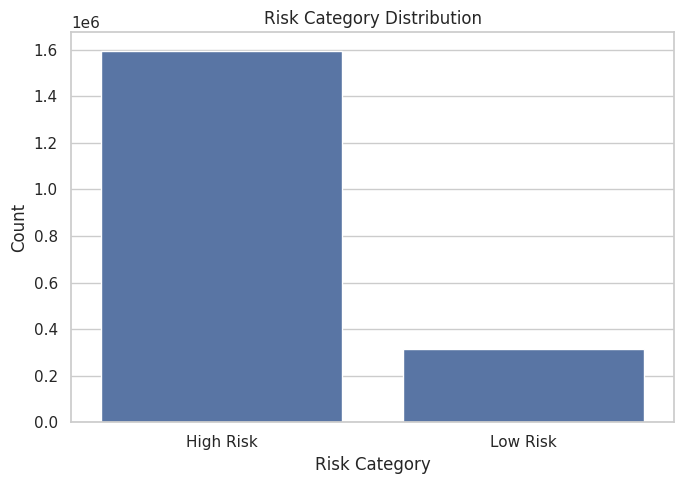

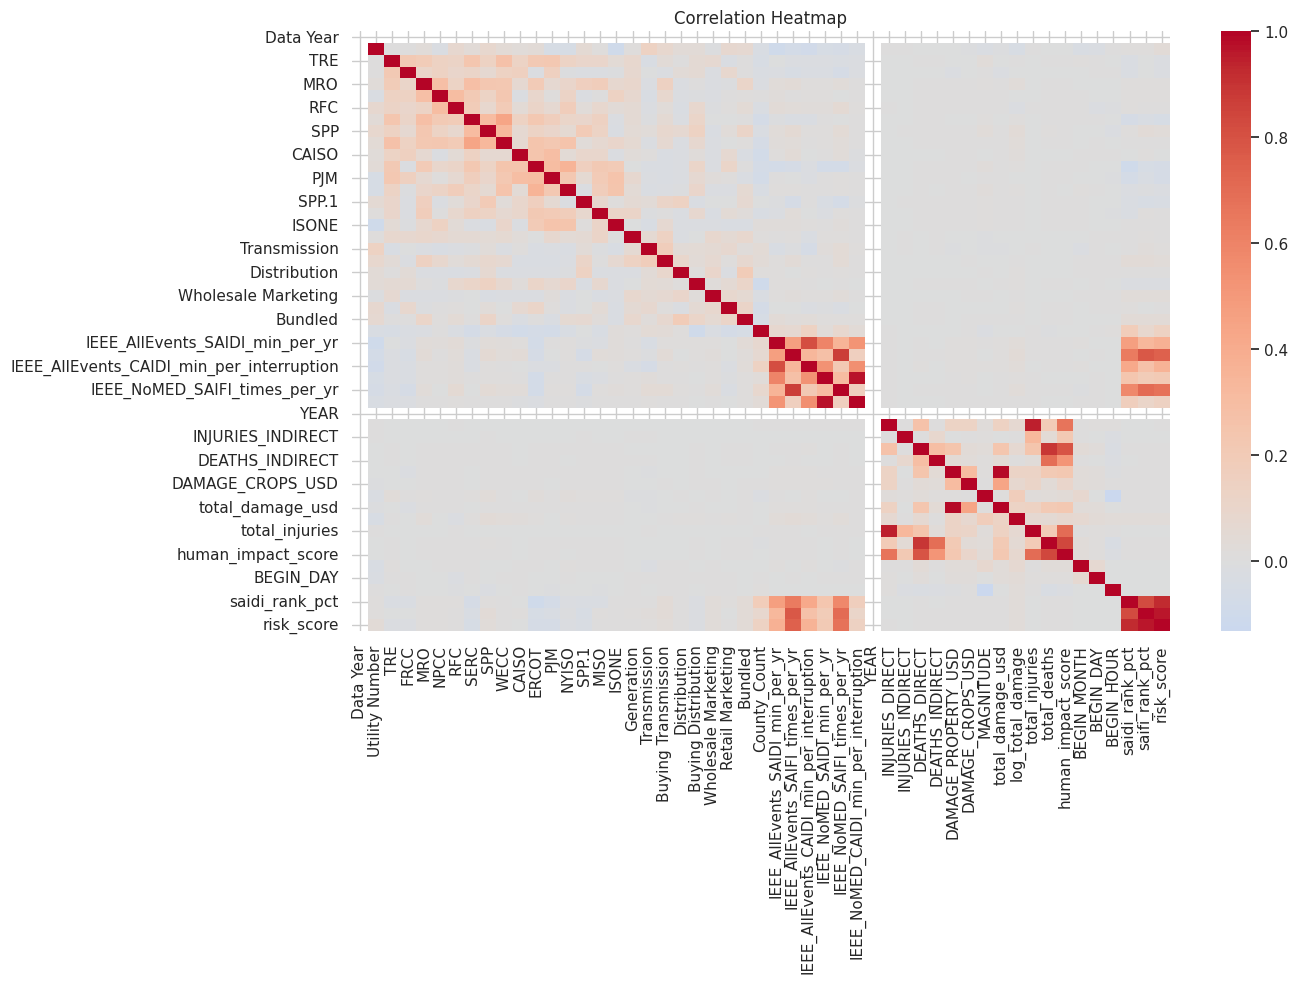

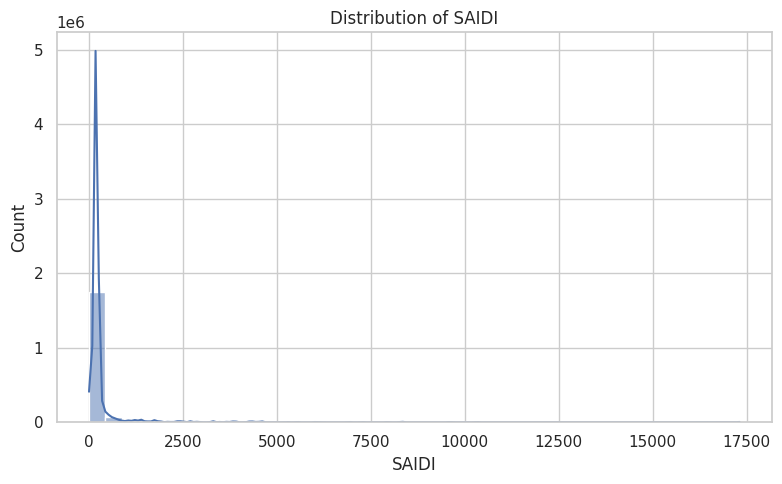

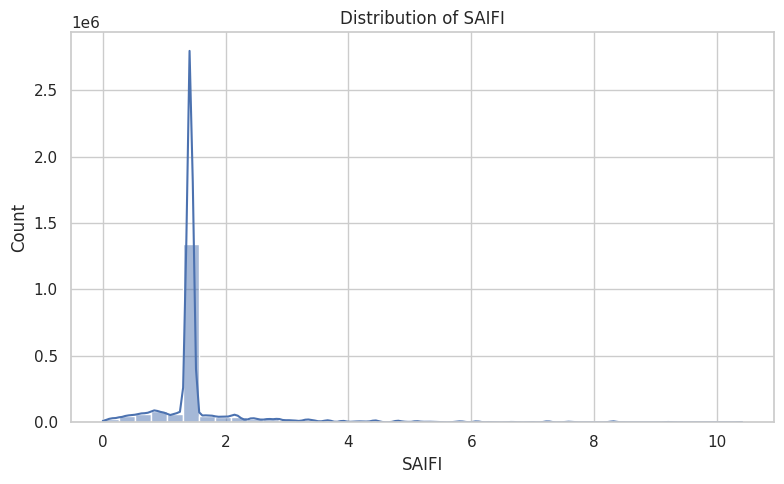

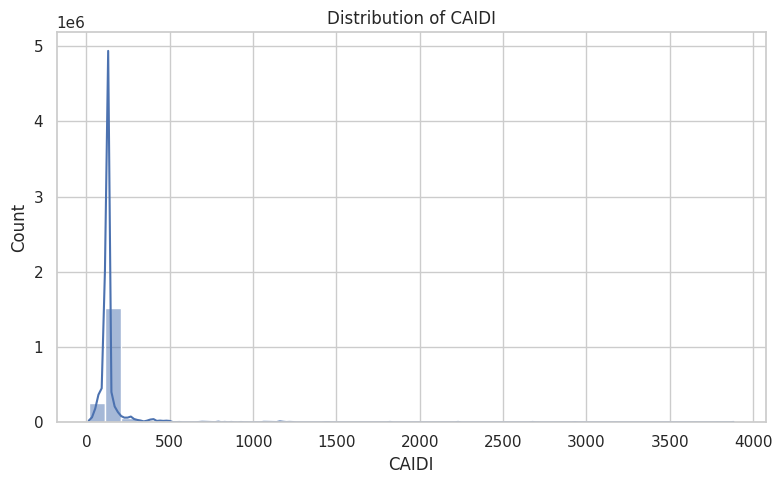

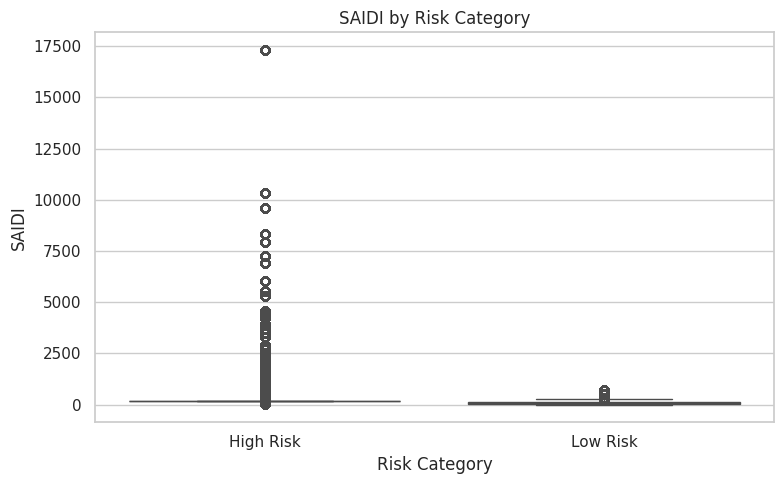

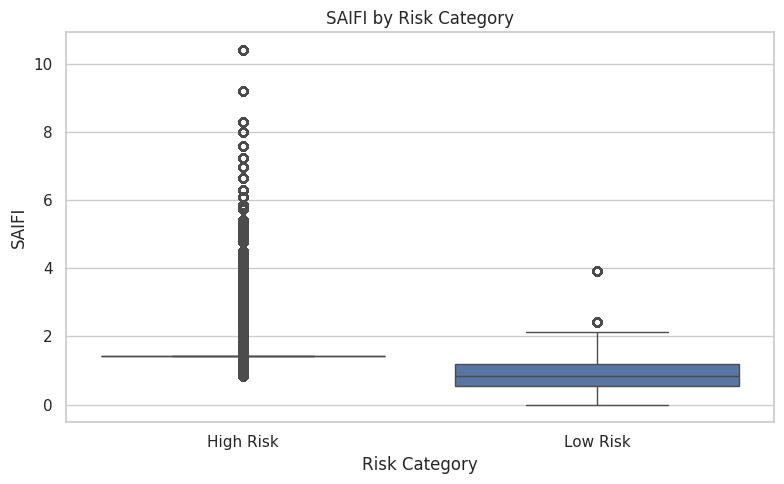

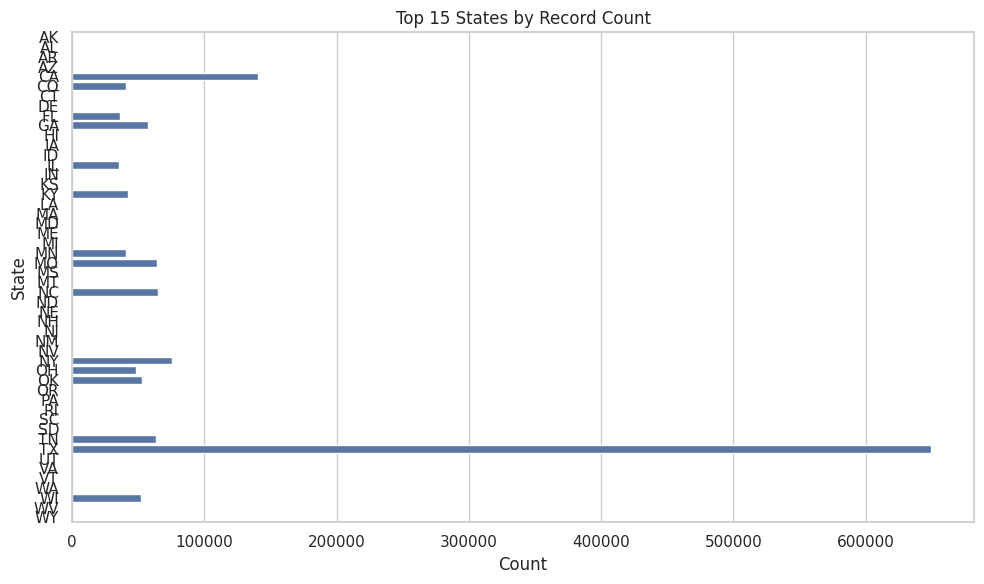

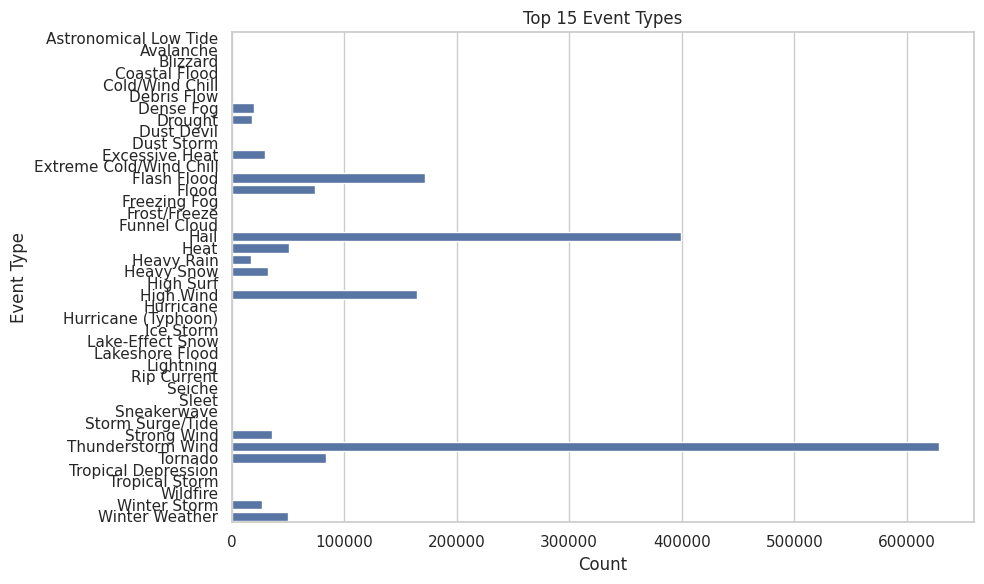

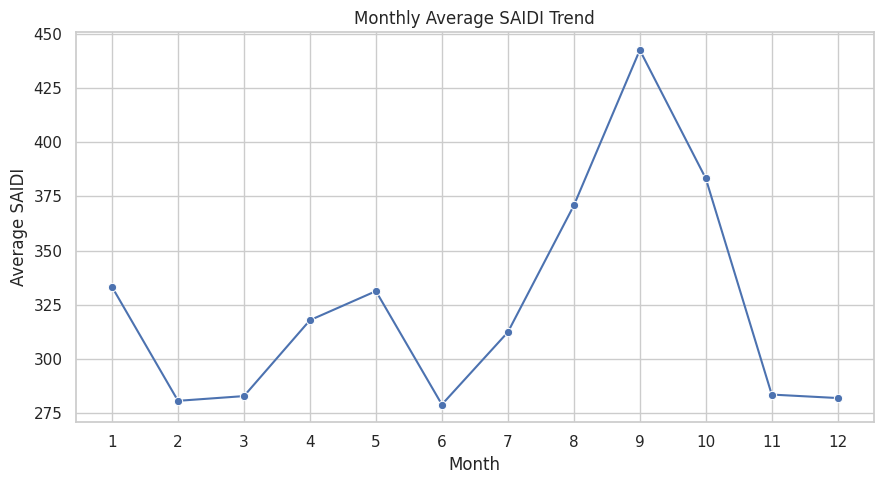

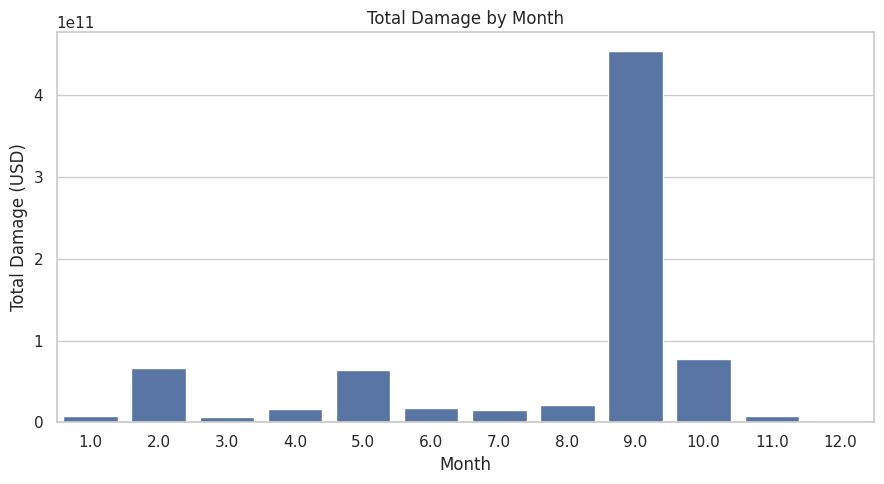

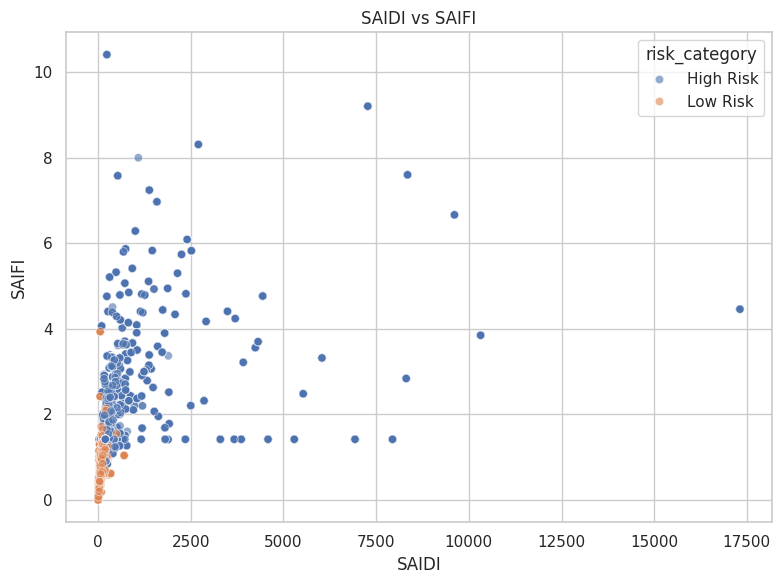


FINAL CHECK
Unique states count should be 50:
50
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


In [2]:

# INPUT  : merged_utility_storm_2024.csv
# OUTPUT : dashboard_clean_dataset.csv / .parquet


import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# USER SETTINGS
INPUT_FILE = "merged_utility_storm_2024.csv"
OUTPUT_DIR = "dashboard_clean_output"
CHUNK_SIZE = 200000   # reduce to 100000 if memory is still low

# Keep only useful columns for dashboard / analyst visuals
KEEP_COLUMNS = [
    "Data Year",
    "Utility Number",
    "Utility Name",
    "State",
    "Ownership",
    "NERC Region",
    "County_Count",
    "Counties_Served",

    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",

    "IEEE_NoMED_SAIDI_min_per_yr",
    "IEEE_NoMED_SAIFI_times_per_yr",
    "IEEE_NoMED_CAIDI_min_per_interruption",

    "EVENT_ID",
    "EPISODE_ID",
    "EVENT_TYPE",
    "CZ_NAME",
    "MONTH_NAME",
    "YEAR",
    "BEGIN_DATE_TIME",
    "END_DATE_TIME",
    "MAGNITUDE",

    "INJURIES_DIRECT",
    "INJURIES_INDIRECT",
    "DEATHS_DIRECT",
    "DEATHS_INDIRECT",

    "DAMAGE_PROPERTY_USD",
    "DAMAGE_CROPS_USD",

    "TRE", "FRCC", "MRO", "NPCC", "RFC", "SERC", "SPP", "WECC",
    "CAISO", "ERCOT", "PJM", "NYISO", "SPP.1", "MISO", "ISONE",
    "Generation", "Transmission", "Buying Transmission", "Distribution",
    "Buying Distribution", "Wholesale Marketing", "Retail Marketing",
    "Bundled"
]

# ============================================================
# KEEP ONLY 50 U.S. STATES
# DC REMOVED
# ============================================================

VALID_US_STATES_ONLY = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY'
}

# ============================================================
# HELPERS
# ============================================================

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def safe_num(series):
    return pd.to_numeric(series, errors="coerce")

def convert_damage_to_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    s = str(x).strip().replace(",", "").replace("$", "")
    if s == "":
        return np.nan

    mult = 1.0
    su = s.upper()

    if su.endswith("K"):
        mult = 1e3
        s = s[:-1]
    elif su.endswith("M"):
        mult = 1e6
        s = s[:-1]
    elif su.endswith("B"):
        mult = 1e9
        s = s[:-1]

    try:
        return float(s) * mult
    except:
        return np.nan

def get_mode(series):
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) > 0 else np.nan


#FIND AVAILABLE COLUMNS


def get_available_columns(input_file):
    sample = pd.read_csv(input_file, nrows=5)
    available = [c for c in KEEP_COLUMNS if c in sample.columns]
    return available


# CLEAN EACH CHUNK


def clean_chunk(df):
    df = df.copy()

    # Keep only 2024
    if "Data Year" in df.columns:
        df["Data Year"] = safe_num(df["Data Year"])
        df = df[df["Data Year"] == 2024].copy()

    # Numeric columns
    numeric_cols = [
        "Data Year",
        "Utility Number",
        "County_Count",
        "IEEE_AllEvents_SAIDI_min_per_yr",
        "IEEE_AllEvents_SAIFI_times_per_yr",
        "IEEE_AllEvents_CAIDI_min_per_interruption",
        "IEEE_NoMED_SAIDI_min_per_yr",
        "IEEE_NoMED_SAIFI_times_per_yr",
        "IEEE_NoMED_CAIDI_min_per_interruption",
        "EVENT_ID",
        "EPISODE_ID",
        "YEAR",
        "MAGNITUDE",
        "INJURIES_DIRECT",
        "INJURIES_INDIRECT",
        "DEATHS_DIRECT",
        "DEATHS_INDIRECT"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = safe_num(df[col])

    # Damage columns
    for col in ["DAMAGE_PROPERTY_USD", "DAMAGE_CROPS_USD"]:
        if col in df.columns:
            df[col] = df[col].apply(convert_damage_to_float)

    # Datetime
    for col in ["BEGIN_DATE_TIME", "END_DATE_TIME"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # Y/N to 1/0
    yn_cols = [
        "TRE", "FRCC", "MRO", "NPCC", "RFC", "SERC", "SPP", "WECC",
        "CAISO", "ERCOT", "PJM", "NYISO", "SPP.1", "MISO", "ISONE",
        "Generation", "Transmission", "Buying Transmission", "Distribution",
        "Buying Distribution", "Wholesale Marketing", "Retail Marketing",
        "Bundled"
    ]

    for col in yn_cols:
        if col in df.columns:
            s = df[col].astype(str).str.strip().str.upper()
            df[col] = np.where(s == "Y", 1, np.where(s == "N", 0, np.nan))

    # Clean text
    object_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in object_cols:
        df[col] = df[col].astype(str).str.strip()
        df.loc[df[col].isin(["", "nan", "None", "NULL"]), col] = np.nan

    # Standardize state
    if "State" in df.columns:
        df["State"] = df["State"].astype(str).str.upper().str.strip()
        df.loc[df["State"].isin(["NAN", "NONE", "NULL", ""]), "State"] = np.nan

    # Feature engineering
    if "DAMAGE_PROPERTY_USD" in df.columns and "DAMAGE_CROPS_USD" in df.columns:
        df["total_damage_usd"] = df["DAMAGE_PROPERTY_USD"].fillna(0) + df["DAMAGE_CROPS_USD"].fillna(0)
        df["log_total_damage"] = np.log1p(df["total_damage_usd"])

    if all(c in df.columns for c in ["INJURIES_DIRECT", "INJURIES_INDIRECT", "DEATHS_DIRECT", "DEATHS_INDIRECT"]):
        df["total_injuries"] = df["INJURIES_DIRECT"].fillna(0) + df["INJURIES_INDIRECT"].fillna(0)
        df["total_deaths"] = df["DEATHS_DIRECT"].fillna(0) + df["DEATHS_INDIRECT"].fillna(0)
        df["human_impact_score"] = df["total_injuries"] + 5 * df["total_deaths"]

    if "BEGIN_DATE_TIME" in df.columns:
        df["BEGIN_MONTH"] = df["BEGIN_DATE_TIME"].dt.month
        df["BEGIN_DAY"] = df["BEGIN_DATE_TIME"].dt.day
        df["BEGIN_HOUR"] = df["BEGIN_DATE_TIME"].dt.hour

    # Risk score
    if "IEEE_AllEvents_SAIDI_min_per_yr" in df.columns and "IEEE_AllEvents_SAIFI_times_per_yr" in df.columns:
        df["saidi_rank_pct"] = df["IEEE_AllEvents_SAIDI_min_per_yr"].rank(pct=True)
        df["saifi_rank_pct"] = df["IEEE_AllEvents_SAIFI_times_per_yr"].rank(pct=True)
        df["risk_score"] = (df["saidi_rank_pct"] + df["saifi_rank_pct"]) / 2

    return df


#CREATE REDUCED CLEAN FILE IN CHUNKS


def create_clean_dataset():
    ensure_dir(OUTPUT_DIR)

    available_cols = get_available_columns(INPUT_FILE)
    print("Keeping columns:", len(available_cols))
    print(available_cols)

    temp_files = []
    chunk_id = 0

    for chunk in pd.read_csv(INPUT_FILE, usecols=available_cols, chunksize=CHUNK_SIZE, low_memory=False):
        print(f"\nProcessing chunk {chunk_id + 1} | shape before clean: {chunk.shape}")

        chunk = clean_chunk(chunk)
        print(f"Chunk {chunk_id + 1} | shape after clean: {chunk.shape}")

        temp_path = os.path.join(OUTPUT_DIR, f"temp_chunk_{chunk_id}.parquet")
        chunk.to_parquet(temp_path, index=False)
        temp_files.append(temp_path)

        del chunk
        gc.collect()
        chunk_id += 1

    print(f"\nTotal temp chunks saved: {len(temp_files)}")

    all_parts = []
    for fp in temp_files:
        all_parts.append(pd.read_parquet(fp))

    df = pd.concat(all_parts, ignore_index=True)

    del all_parts
    gc.collect()

    print("\nCombined shape:", df.shape)

    # Keep only valid 50 U.S. states
    if "State" in df.columns:
        before_rows = len(df)
        df = df[df["State"].isin(VALID_US_STATES_ONLY)].copy()
        print(f"Rows after keeping valid 50 U.S. states only: {df.shape[0]:,} (removed {before_rows - len(df):,})")

    # Drop unnecessary columns for dashboard
    drop_cols = []

    for c in ["BEGIN_DATE_TIME", "END_DATE_TIME"]:
        if c in df.columns:
            drop_cols.append(c)

    for c in ["EVENT_ID", "EPISODE_ID"]:
        if c in df.columns:
            drop_cols.append(c)

    for c in ["Counties_Served", "CZ_NAME"]:
        if c in df.columns:
            drop_cols.append(c)

    df = df.drop(columns=drop_cols, errors="ignore")
    print("Shape after dropping unnecessary columns:", df.shape)

    # Remove duplicates
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        df = df.drop_duplicates().copy()
        print(f"Removed duplicate rows: {dup_count:,}")

    # Imputation
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in df.columns if c not in numeric_cols]

    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        if df[col].isna().any():
            mode_val = get_mode(df[col])
            if pd.isna(mode_val):
                mode_val = "Unknown"
            df[col] = df[col].fillna(mode_val)

    # Final risk category
    if "risk_score" in df.columns:
        q80 = df["risk_score"].quantile(0.80)
        q50 = df["risk_score"].quantile(0.50)
        df["risk_category"] = np.where(
            df["risk_score"] >= q80, "High Risk",
            np.where(df["risk_score"] >= q50, "Medium Risk", "Low Risk")
        )

    # Memory optimization
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")

    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    for col in ["State", "Ownership", "NERC Region", "EVENT_TYPE", "MONTH_NAME", "risk_category"]:
        if col in df.columns:
            df[col] = df[col].astype("category")

    # Save final dataset
    csv_path = os.path.join(OUTPUT_DIR, "dashboard_clean_dataset.csv")
    parquet_path = os.path.join(OUTPUT_DIR, "dashboard_clean_dataset.parquet")

    df.to_csv(csv_path, index=False)
    df.to_parquet(parquet_path, index=False)

    print("\nSaved final clean dataset:")
    print(csv_path)
    print(parquet_path)

    print("\nFinal shape:", df.shape)
    print("Final columns:", len(df.columns))
    print(df.columns.tolist())

    return df


# EDA + VISUALIZATION


def run_eda(df):
    print("\n" + "="*70)
    print("EDA SUMMARY")
    print("="*70)

    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))

    print("\nDuplicate rows:", df.duplicated().sum())

    if "State" in df.columns:
        print("\nUnique states count:", df["State"].nunique())
        print("States present:")
        print(sorted(df["State"].astype(str).unique().tolist()))

    if "risk_category" in df.columns:
        print("\nRisk category counts:")
        print(df["risk_category"].value_counts())

        print("\nRisk category percentages:")
        print((df["risk_category"].value_counts(normalize=True) * 100).round(2))

    print("\nNumeric summary:")
    print(df.select_dtypes(include=np.number).describe().T)

    if "State" in df.columns:
        print("\nTop 10 states by record count:")
        print(df["State"].value_counts().head(10))

    if "EVENT_TYPE" in df.columns:
        print("\nTop 10 event types:")
        print(df["EVENT_TYPE"].value_counts().head(10))

    compare_cols = [
        "IEEE_AllEvents_SAIDI_min_per_yr",
        "IEEE_AllEvents_SAIFI_times_per_yr",
        "IEEE_AllEvents_CAIDI_min_per_interruption",
        "total_damage_usd",
        "total_injuries",
        "total_deaths",
        "human_impact_score",
        "risk_score"
    ]
    compare_cols = [c for c in compare_cols if c in df.columns]

    if "risk_category" in df.columns and compare_cols:
        print("\nAverage numeric values by risk category:")
        print(df.groupby("risk_category", observed=False)[compare_cols].mean().round(2))

    sns.set_theme(style="whitegrid")

    # 1. Missing values bar (top 20)
    missing_nonzero = missing[missing > 0].sort_values(ascending=False).head(20)
    if len(missing_nonzero) > 0:
        plt.figure(figsize=(12, 5))
        sns.barplot(x=missing_nonzero.index, y=missing_nonzero.values)
        plt.title("Top Missing Values")
        plt.xticks(rotation=75)
        plt.ylabel("Missing Count")
        plt.tight_layout()
        plt.show()

    # 2. Risk distribution
    if "risk_category" in df.columns:
        plt.figure(figsize=(7, 5))
        sns.countplot(data=df, x="risk_category", order=df["risk_category"].value_counts().index)
        plt.title("Risk Category Distribution")
        plt.xlabel("Risk Category")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    # 3. Correlation heatmap
    corr_df = df.select_dtypes(include=np.number)
    if corr_df.shape[1] > 1:
        plt.figure(figsize=(14, 10))
        sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0)
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    # 4. SAIDI distribution
    if "IEEE_AllEvents_SAIDI_min_per_yr" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df["IEEE_AllEvents_SAIDI_min_per_yr"], kde=True, bins=40)
        plt.title("Distribution of SAIDI")
        plt.xlabel("SAIDI")
        plt.tight_layout()
        plt.show()

    # 5. SAIFI distribution
    if "IEEE_AllEvents_SAIFI_times_per_yr" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df["IEEE_AllEvents_SAIFI_times_per_yr"], kde=True, bins=40)
        plt.title("Distribution of SAIFI")
        plt.xlabel("SAIFI")
        plt.tight_layout()
        plt.show()

    # 6. CAIDI distribution
    if "IEEE_AllEvents_CAIDI_min_per_interruption" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df["IEEE_AllEvents_CAIDI_min_per_interruption"], kde=True, bins=40)
        plt.title("Distribution of CAIDI")
        plt.xlabel("CAIDI")
        plt.tight_layout()
        plt.show()

    # 7. SAIDI vs risk category
    if "risk_category" in df.columns and "IEEE_AllEvents_SAIDI_min_per_yr" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x="risk_category", y="IEEE_AllEvents_SAIDI_min_per_yr")
        plt.title("SAIDI by Risk Category")
        plt.xlabel("Risk Category")
        plt.ylabel("SAIDI")
        plt.tight_layout()
        plt.show()

    # 8. SAIFI vs risk category
    if "risk_category" in df.columns and "IEEE_AllEvents_SAIFI_times_per_yr" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x="risk_category", y="IEEE_AllEvents_SAIFI_times_per_yr")
        plt.title("SAIFI by Risk Category")
        plt.xlabel("Risk Category")
        plt.ylabel("SAIFI")
        plt.tight_layout()
        plt.show()

    # 9. Top states
    if "State" in df.columns:
        top_states = df["State"].value_counts().head(15)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_states.values, y=top_states.index)
        plt.title("Top 15 States by Record Count")
        plt.xlabel("Count")
        plt.ylabel("State")
        plt.tight_layout()
        plt.show()

    # 10. Top event types
    if "EVENT_TYPE" in df.columns:
        top_events = df["EVENT_TYPE"].value_counts().head(15)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_events.values, y=top_events.index)
        plt.title("Top 15 Event Types")
        plt.xlabel("Count")
        plt.ylabel("Event Type")
        plt.tight_layout()
        plt.show()

    # 11. Monthly trend
    if "BEGIN_MONTH" in df.columns and "IEEE_AllEvents_SAIDI_min_per_yr" in df.columns:
        month_trend = df.groupby("BEGIN_MONTH", observed=False)["IEEE_AllEvents_SAIDI_min_per_yr"].mean().reset_index()
        plt.figure(figsize=(9, 5))
        sns.lineplot(data=month_trend, x="BEGIN_MONTH", y="IEEE_AllEvents_SAIDI_min_per_yr", marker="o")
        plt.title("Monthly Average SAIDI Trend")
        plt.xlabel("Month")
        plt.ylabel("Average SAIDI")
        plt.xticks(range(1, 13))
        plt.tight_layout()
        plt.show()

    # 12. Damage by month
    if "BEGIN_MONTH" in df.columns and "total_damage_usd" in df.columns:
        damage_month = df.groupby("BEGIN_MONTH", observed=False)["total_damage_usd"].sum().reset_index()
        plt.figure(figsize=(9, 5))
        sns.barplot(data=damage_month, x="BEGIN_MONTH", y="total_damage_usd")
        plt.title("Total Damage by Month")
        plt.xlabel("Month")
        plt.ylabel("Total Damage (USD)")
        plt.tight_layout()
        plt.show()

    # 13. SAIDI vs SAIFI scatter
    if "IEEE_AllEvents_SAIDI_min_per_yr" in df.columns and "IEEE_AllEvents_SAIFI_times_per_yr" in df.columns:
        sample_df = df.sample(min(20000, len(df)), random_state=42)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=sample_df,
            x="IEEE_AllEvents_SAIDI_min_per_yr",
            y="IEEE_AllEvents_SAIFI_times_per_yr",
            hue="risk_category" if "risk_category" in sample_df.columns else None,
            alpha=0.6
        )
        plt.title("SAIDI vs SAIFI")
        plt.xlabel("SAIDI")
        plt.ylabel("SAIFI")
        plt.tight_layout()
        plt.show()


# MAIN
if __name__ == "__main__":
    final_df = create_clean_dataset()
    run_eda(final_df)

    print("\n" + "="*70)
    print("FINAL CHECK")
    print("="*70)
    print("Unique states count should be 50:")
    print(final_df["State"].nunique())
    print(sorted(final_df["State"].astype(str).unique().tolist()))

In [3]:

# DASHBOARD WEBSITE FOR GOOGLE COLAB
import os
import json
import socket
import threading
import warnings
from functools import lru_cache
from urllib.parse import urlparse, parse_qs
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer

import numpy as np
import pandas as pd
from IPython.display import display, HTML
from google.colab import output
from google.colab.output import eval_js

warnings.filterwarnings("ignore")

# SETTINGS
DATA_PATH = "/content/dashboard_clean_output/dashboard_clean_dataset.parquet"
POINT_SAMPLE_SIZE = 5000
TOP_N_EVENTS = 10
TOP_N_UTILITIES = 25

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found: {DATA_PATH}")


#LOAD DATA

df = pd.read_parquet(DATA_PATH)


# Cleanup

for col in df.columns:
    if pd.api.types.is_categorical_dtype(df[col]):
        df[col] = df[col].astype("object")

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip()
    df.loc[df[col].isin(["nan", "None", "NULL", ""]), col] = np.nan

if "State" in df.columns:
    df["State"] = df["State"].astype(str).str.upper().str.strip()

# Build missing fields safely

if "risk_category" not in df.columns and "risk_score" in df.columns:
    q80 = df["risk_score"].quantile(0.80)
    q50 = df["risk_score"].quantile(0.50)
    df["risk_category"] = np.where(
        df["risk_score"] >= q80,
        "High Risk",
        np.where(df["risk_score"] >= q50, "Medium Risk", "Low Risk")
    )

if "total_damage_usd" not in df.columns and {"DAMAGE_PROPERTY_USD", "DAMAGE_CROPS_USD"}.issubset(df.columns):
    df["total_damage_usd"] = (
        pd.to_numeric(df["DAMAGE_PROPERTY_USD"], errors="coerce").fillna(0) +
        pd.to_numeric(df["DAMAGE_CROPS_USD"], errors="coerce").fillna(0)
    )

if "log_total_damage" not in df.columns and "total_damage_usd" in df.columns:
    df["log_total_damage"] = np.log1p(pd.to_numeric(df["total_damage_usd"], errors="coerce").fillna(0))

if "total_injuries" not in df.columns and {"INJURIES_DIRECT", "INJURIES_INDIRECT"}.issubset(df.columns):
    df["total_injuries"] = (
        pd.to_numeric(df["INJURIES_DIRECT"], errors="coerce").fillna(0) +
        pd.to_numeric(df["INJURIES_INDIRECT"], errors="coerce").fillna(0)
    )

if "total_deaths" not in df.columns and {"DEATHS_DIRECT", "DEATHS_INDIRECT"}.issubset(df.columns):
    df["total_deaths"] = (
        pd.to_numeric(df["DEATHS_DIRECT"], errors="coerce").fillna(0) +
        pd.to_numeric(df["DEATHS_INDIRECT"], errors="coerce").fillna(0)
    )

if "human_impact_score" not in df.columns and {"total_injuries", "total_deaths"}.issubset(df.columns):
    df["human_impact_score"] = df["total_injuries"].fillna(0) + 5 * df["total_deaths"].fillna(0)

# Ensure numeric

numeric_cols = [
    "Utility Number",
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "total_damage_usd",
    "log_total_damage",
    "total_injuries",
    "total_deaths",
    "human_impact_score",
    "risk_score",
    "BEGIN_MONTH",
    "BEGIN_HOUR",
    "MAGNITUDE",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")


# Fill important text

text_cols = ["Utility Name", "State", "Ownership", "EVENT_TYPE", "risk_category"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

if "BEGIN_MONTH" in df.columns:
    df["BEGIN_MONTH"] = df["BEGIN_MONTH"].fillna(1).astype(int).clip(1, 12)

print(f" Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


# KEEP ONLY DASHBOARD COLUMNS

keep_cols = [c for c in [
    "Utility Name",
    "Utility Number",
    "State",
    "Ownership",
    "EVENT_TYPE",
    "risk_category",
    "risk_score",
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "total_damage_usd",
    "log_total_damage",
    "total_injuries",
    "total_deaths",
    "human_impact_score",
    "BEGIN_MONTH",
    "MAGNITUDE",
] if c in df.columns]

df_dash = df[keep_cols].copy()

# memory optimization
for c in ["State", "Ownership", "EVENT_TYPE", "risk_category"]:
    if c in df_dash.columns:
        df_dash[c] = df_dash[c].astype("category")

for c in df_dash.select_dtypes(include=["float64"]).columns:
    df_dash[c] = pd.to_numeric(df_dash[c], downcast="float")

for c in df_dash.select_dtypes(include=["int64"]).columns:
    df_dash[c] = pd.to_numeric(df_dash[c], downcast="integer")


# LOCATION PREP FOR LEAFLET MAP

STATE_GEO = {
    "AL":[32.31,-86.90],"AK":[64.20,-153.37],"AZ":[34.27,-111.43],"AR":[34.89,-92.37],
    "CA":[36.78,-119.42],"CO":[39.55,-105.78],"CT":[41.60,-72.64],"DE":[38.99,-75.50],
    "FL":[27.99,-81.76],"GA":[33.04,-83.64],"HI":[20.79,-156.33],"ID":[44.07,-114.74],
    "IL":[40.35,-88.99],"IN":[39.76,-86.13],"IA":[42.00,-93.21],"KS":[38.52,-96.72],
    "KY":[37.67,-84.67],"LA":[30.99,-91.96],"ME":[44.69,-69.38],"MD":[39.04,-76.64],
    "MA":[42.23,-71.53],"MI":[44.31,-85.60],"MN":[46.39,-94.64],"MS":[32.74,-89.67],
    "MO":[38.46,-92.29],"MT":[46.88,-110.36],"NE":[41.49,-99.90],"NV":[38.80,-116.42],
    "NH":[43.19,-71.57],"NJ":[40.06,-74.41],"NM":[34.84,-106.25],"NY":[42.96,-75.37],
    "NC":[35.63,-79.81],"ND":[47.52,-99.78],"OH":[40.36,-82.99],"OK":[35.56,-96.92],
    "OR":[44.57,-122.07],"PA":[41.20,-77.19],"RI":[41.70,-71.51],"SC":[33.84,-80.90],
    "SD":[44.37,-100.35],"TN":[35.86,-86.35],"TX":[31.97,-99.90],"UT":[39.32,-111.09],
    "VT":[44.05,-72.71],"VA":[37.77,-78.17],"WA":[47.40,-120.56],"WV":[38.64,-80.62],
    "WI":[44.26,-89.62],"WY":[42.75,-107.30]
}

lat_candidates = [c for c in df.columns if "lat" in c.lower()]
lon_candidates = [c for c in df.columns if ("lon" in c.lower() or "lng" in c.lower() or "long" in c.lower())]

if lat_candidates and lon_candidates:
    lat_col = lat_candidates[0]
    lon_col = lon_candidates[0]
    df_dash["lat"] = pd.to_numeric(df[lat_col], errors="coerce")
    df_dash["lon"] = pd.to_numeric(df[lon_col], errors="coerce")
    print(f" Using real coordinates: {lat_col}, {lon_col}")
else:
    rng = np.random.default_rng(42)
    df_dash["lat"] = df_dash["State"].astype(str).map(lambda s: STATE_GEO.get(s, [39.5, -98.35])[0])
    df_dash["lon"] = df_dash["State"].astype(str).map(lambda s: STATE_GEO.get(s, [39.5, -98.35])[1])
    df_dash["lat"] = df_dash["lat"] + rng.uniform(-1.6, 1.6, len(df_dash))
    df_dash["lon"] = df_dash["lon"] + rng.uniform(-1.6, 1.6, len(df_dash))
    print("ℹ No true lat/lon found. Using state centroids + jitter for spatial visualization.")


#FILTER OPTIONS

STATE_OPTIONS = ["All"] + sorted(df_dash["State"].dropna().astype(str).unique().tolist())
OWNERSHIP_OPTIONS = ["All"] + sorted(df_dash["Ownership"].dropna().astype(str).unique().tolist()) if "Ownership" in df_dash.columns else ["All"]
EVENT_OPTIONS = ["All"] + sorted(df_dash["EVENT_TYPE"].dropna().astype(str).unique().tolist()) if "EVENT_TYPE" in df_dash.columns else ["All"]
RISK_OPTIONS = ["All", "High Risk", "Medium Risk", "Low Risk"]


#  HELPERS

def clean_record_dict(df_in):
    return json.loads(df_in.to_json(orient="records"))

def get_filtered_df(state="All", ownership="All", event="All", risk="All", month_min=1, month_max=12):
    temp = df_dash
    mask = pd.Series(True, index=temp.index)

    if state != "All" and "State" in temp.columns:
        mask &= temp["State"].astype(str) == state
    if ownership != "All" and "Ownership" in temp.columns:
        mask &= temp["Ownership"].astype(str) == ownership
    if event != "All" and "EVENT_TYPE" in temp.columns:
        mask &= temp["EVENT_TYPE"].astype(str) == event
    if risk != "All" and "risk_category" in temp.columns:
        mask &= temp["risk_category"].astype(str) == risk
    if "BEGIN_MONTH" in temp.columns:
        mask &= temp["BEGIN_MONTH"].between(month_min, month_max)

    return temp.loc[mask].copy()

def make_payload(filtered_df, top_n=TOP_N_EVENTS, point_sample_size=POINT_SAMPLE_SIZE):
    if filtered_df.empty:
        return {
            "kpi": {},
            "insights": {},
            "risk": {"labels": [], "values": []},
            "states": [],
            "months": [],
            "events": [],
            "top_utilities": [],
            "points": [],
            "state_month": []
        }

    if len(filtered_df) > point_sample_size:
        point_df = filtered_df.sample(point_sample_size, random_state=42).copy()
    else:
        point_df = filtered_df.copy()

    kpi = {
        "total_rows": int(len(filtered_df)),
        "total_utilities": int(filtered_df["Utility Number"].nunique()) if "Utility Number" in filtered_df.columns else 0,
        "total_states": int(filtered_df["State"].nunique()) if "State" in filtered_df.columns else 0,
        "avg_saidi": float(filtered_df["IEEE_AllEvents_SAIDI_min_per_yr"].mean()) if "IEEE_AllEvents_SAIDI_min_per_yr" in filtered_df.columns else 0,
        "avg_saifi": float(filtered_df["IEEE_AllEvents_SAIFI_times_per_yr"].mean()) if "IEEE_AllEvents_SAIFI_times_per_yr" in filtered_df.columns else 0,
        "avg_caidi": float(filtered_df["IEEE_AllEvents_CAIDI_min_per_interruption"].mean()) if "IEEE_AllEvents_CAIDI_min_per_interruption" in filtered_df.columns else 0,
        "total_damage": float(filtered_df["total_damage_usd"].sum()) if "total_damage_usd" in filtered_df.columns else 0,
        "total_injuries": float(filtered_df["total_injuries"].sum()) if "total_injuries" in filtered_df.columns else 0,
        "total_deaths": float(filtered_df["total_deaths"].sum()) if "total_deaths" in filtered_df.columns else 0,
        "high_risk": int((filtered_df["risk_category"].astype(str) == "High Risk").sum()) if "risk_category" in filtered_df.columns else 0,
        "medium_risk": int((filtered_df["risk_category"].astype(str) == "Medium Risk").sum()) if "risk_category" in filtered_df.columns else 0,
        "low_risk": int((filtered_df["risk_category"].astype(str) == "Low Risk").sum()) if "risk_category" in filtered_df.columns else 0,
    }

    insights = {
        "high_risk_records": kpi["high_risk"],
        "top_state_saidi": None,
        "top_state_saidi_value": None,
        "top_event_damage": None,
        "top_event_damage_value": None
    }

    if {"State", "IEEE_AllEvents_SAIDI_min_per_yr"}.issubset(filtered_df.columns):
        tmp = filtered_df.groupby("State", observed=True)["IEEE_AllEvents_SAIDI_min_per_yr"].mean().sort_values(ascending=False)
        if len(tmp) > 0:
            insights["top_state_saidi"] = str(tmp.index[0])
            insights["top_state_saidi_value"] = float(tmp.iloc[0])

    if {"EVENT_TYPE", "total_damage_usd"}.issubset(filtered_df.columns):
        tmp = filtered_df.groupby("EVENT_TYPE", observed=True)["total_damage_usd"].sum().sort_values(ascending=False)
        if len(tmp) > 0:
            insights["top_event_damage"] = str(tmp.index[0])
            insights["top_event_damage_value"] = float(tmp.iloc[0])

    risk_counts = filtered_df["risk_category"].astype(str).value_counts()
    risk = {
        "labels": risk_counts.index.tolist(),
        "values": [int(v) for v in risk_counts.values.tolist()]
    }

    state_df = filtered_df.groupby("State", observed=True).agg(
        avg_saidi=("IEEE_AllEvents_SAIDI_min_per_yr", "mean"),
        avg_saifi=("IEEE_AllEvents_SAIFI_times_per_yr", "mean"),
        avg_caidi=("IEEE_AllEvents_CAIDI_min_per_interruption", "mean"),
        total_damage=("total_damage_usd", "sum"),
        total_injuries=("total_injuries", "sum"),
        total_deaths=("total_deaths", "sum"),
        utility_count=("Utility Number", "nunique"),
        high_risk_count=("risk_category", lambda s: (s.astype(str) == "High Risk").sum())
    ).reset_index()

    month_df = filtered_df.groupby("BEGIN_MONTH", observed=True).agg(
        avg_saidi=("IEEE_AllEvents_SAIDI_min_per_yr", "mean"),
        avg_saifi=("IEEE_AllEvents_SAIFI_times_per_yr", "mean"),
        avg_caidi=("IEEE_AllEvents_CAIDI_min_per_interruption", "mean"),
        total_damage=("total_damage_usd", "sum"),
        total_injuries=("total_injuries", "sum"),
        total_deaths=("total_deaths", "sum"),
        high_risk_count=("risk_category", lambda s: (s.astype(str) == "High Risk").sum())
    ).reset_index().sort_values("BEGIN_MONTH")

    event_df = filtered_df.groupby("EVENT_TYPE", observed=True).agg(
        count=("EVENT_TYPE", "size"),
        avg_saidi=("IEEE_AllEvents_SAIDI_min_per_yr", "mean"),
        avg_saifi=("IEEE_AllEvents_SAIFI_times_per_yr", "mean"),
        total_damage=("total_damage_usd", "sum"),
        total_injuries=("total_injuries", "sum"),
        total_deaths=("total_deaths", "sum")
    ).reset_index().sort_values("count", ascending=False).head(top_n)

    top_util_df = filtered_df.sort_values("risk_score", ascending=False).head(TOP_N_UTILITIES).copy()

    state_month_df = filtered_df.groupby(["BEGIN_MONTH", "State"], observed=True).agg(
        avg_saidi=("IEEE_AllEvents_SAIDI_min_per_yr", "mean"),
        avg_saifi=("IEEE_AllEvents_SAIFI_times_per_yr", "mean"),
        avg_caidi=("IEEE_AllEvents_CAIDI_min_per_interruption", "mean"),
        total_damage=("total_damage_usd", "sum"),
        total_injuries=("total_injuries", "sum"),
        total_deaths=("total_deaths", "sum"),
        high_risk_count=("risk_category", lambda s: (s.astype(str) == "High Risk").sum()),
        utility_count=("Utility Number", "nunique")
    ).reset_index()

    rename_map = {
        "Utility Name": "utility_name",
        "Utility Number": "utility_number",
        "State": "state",
        "Ownership": "ownership",
        "EVENT_TYPE": "event_type",
        "risk_category": "risk_category",
        "risk_score": "risk_score",
        "IEEE_AllEvents_SAIDI_min_per_yr": "saidi",
        "IEEE_AllEvents_SAIFI_times_per_yr": "saifi",
        "IEEE_AllEvents_CAIDI_min_per_interruption": "caidi",
        "total_damage_usd": "damage",
        "log_total_damage": "log_damage",
        "total_injuries": "injuries",
        "total_deaths": "deaths",
        "human_impact_score": "impact",
        "BEGIN_MONTH": "month",
        "MAGNITUDE": "magnitude",
        "lat": "lat",
        "lon": "lon"
    }

    state_df = state_df.rename(columns=rename_map)
    month_df = month_df.rename(columns=rename_map)
    event_df = event_df.rename(columns=rename_map)
    top_util_df = top_util_df.rename(columns=rename_map)
    state_month_df = state_month_df.rename(columns=rename_map)
    point_df = point_df.rename(columns=rename_map)

    return {
        "kpi": kpi,
        "insights": insights,
        "risk": risk,
        "states": clean_record_dict(state_df),
        "months": clean_record_dict(month_df),
        "events": clean_record_dict(event_df),
        "top_utilities": clean_record_dict(top_util_df),
        "points": clean_record_dict(point_df),
        "state_month": clean_record_dict(state_month_df),
    }

@lru_cache(maxsize=128)
def get_payload_cached(state, ownership, event, risk, month_min, month_max, top_n):
    filtered_df = get_filtered_df(
        state=state,
        ownership=ownership,
        event=event,
        risk=risk,
        month_min=month_min,
        month_max=month_max
    )
    return make_payload(filtered_df, top_n=top_n, point_sample_size=POINT_SAMPLE_SIZE)


# HTML TEMPLATE

HTML_TEMPLATE = r"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Power Outage Risk Dashboard</title>

<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<link rel="stylesheet" href="https://unpkg.com/leaflet.markercluster@1.5.3/dist/MarkerCluster.css"/>
<link rel="stylesheet" href="https://unpkg.com/leaflet.markercluster@1.5.3/dist/MarkerCluster.Default.css"/>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://unpkg.com/leaflet.markercluster@1.5.3/dist/leaflet.markercluster.js"></script>

<style>
  :root{
    --bg:#202124;
    --panel:#111827;
    --border:#374151;
    --text:#ffffff;
    --muted:#d1d5db;
    --blue:#2196f3;
  }
  *{box-sizing:border-box}
  body{margin:0;font-family:Arial,sans-serif;background:var(--bg);color:var(--text)}
  .container{padding:18px}
  .title{font-size:34px;font-weight:700;margin-bottom:6px}
  .subtitle{color:var(--muted);margin-bottom:18px;font-size:16px}
  .filters{
    display:grid;grid-template-columns:1fr 1fr;gap:16px;
    background:linear-gradient(135deg,#07142f,#091b42);
    border:1px solid var(--border);
    border-radius:16px;padding:16px;margin-bottom:18px;
    box-shadow:0 6px 20px rgba(0,0,0,.18)
  }
  .filter-col{display:flex;flex-direction:column;gap:12px}
  .filter-group label{display:block;font-size:13px;margin-bottom:4px;color:var(--muted)}
  .filter-group select,.filter-group input{
    width:100%;padding:10px;border-radius:12px;border:1px solid #4b5563;background:#374151;color:white
  }
  .btn{
    padding:11px 16px;background:var(--blue);color:white;border:none;border-radius:12px;
    cursor:pointer;font-weight:700;box-shadow:0 4px 12px rgba(33,150,243,.25)
  }
  .kpis{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:18px}
  .kpi{
    border-radius:18px;padding:16px;color:#111827;
    box-shadow:0 8px 18px rgba(0,0,0,.10);
    transition:transform .2s ease, box-shadow .2s ease
  }
  .kpi:hover{transform:translateY(-4px);box-shadow:0 12px 24px rgba(0,0,0,.16)}
  .kpi .label{font-size:14px;color:#374151;margin-bottom:8px}
  .kpi .value{font-size:24px;font-weight:800}
  .insight{
    background:linear-gradient(135deg,#07142f,#091b42);
    border:1px solid var(--border);border-left:6px solid #3b82f6;
    border-radius:14px;padding:16px;margin-bottom:18px
  }
  .insight-title{font-size:18px;font-weight:700;margin-bottom:8px}
  .section{margin-top:18px;margin-bottom:10px;font-size:28px;font-weight:700}
  .grid-2{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:16px}
  .card{
    background:var(--panel);
    border:1px solid var(--border);
    border-radius:16px;padding:10px;
    box-shadow:0 6px 20px rgba(0,0,0,.15)
  }
  .plot{width:100%;height:430px}
  .plot-tall{width:100%;height:620px}
  .plot-map{width:100%;height:700px}
  .leaflet-map{width:100%;height:720px;border-radius:12px;overflow:hidden}
  .map-toolbar{display:flex;gap:8px;margin-bottom:10px;flex-wrap:wrap}
  .map-tab{padding:8px 12px;border-radius:10px;border:1px solid var(--border);background:#1f2937;color:white;cursor:pointer}
  .map-tab.active{background:#2563eb;border-color:#2563eb}
  .table-wrap{
    background:var(--panel);
    border:1px solid var(--border);
    border-radius:16px;padding:12px;overflow-x:auto
  }
  table{width:100%;border-collapse:collapse;color:white}
  th,td{padding:10px;border-bottom:1px solid var(--border);text-align:left;font-size:13px}
  th{color:#93c5fd}
  .legend-note{color:#cbd5e1;font-size:13px;margin-top:6px}
  .small-muted{font-size:12px;color:#6b7280}
  .sparkline{margin-top:8px}
  .loading{
    position:fixed; inset:0; background:rgba(0,0,0,0.45);
    display:none; align-items:center; justify-content:center; z-index:9999;
  }
  .loading-box{
    background:#111827; color:white; padding:18px 24px; border-radius:14px;
    border:1px solid #374151; font-size:16px; box-shadow:0 8px 24px rgba(0,0,0,.25)
  }
  @media (max-width:1200px){
    .kpis{grid-template-columns:repeat(2,1fr)}
    .grid-2,.filters{grid-template-columns:1fr}
  }
</style>
</head>
<body>
<div class="loading" id="loadingOverlay">
  <div class="loading-box">Updating dashboard...</div>
</div>

<div class="container">
  <div class="title">Power Outage Risk Dashboard</div>
  <div class="subtitle">Optimized interactive dashboard for outage reliability, storm events, damage, utility risk, maps, and trends.</div>

  <div class="filters">
    <div class="filter-col">
      <div class="filter-group"><label>State</label><select id="stateFilter"></select></div>
      <div class="filter-group"><label>Ownership</label><select id="ownershipFilter"></select></div>
      <div class="filter-group"><label>Event</label><select id="eventFilter"></select></div>
      <div class="filter-group"><label>Risk</label><select id="riskFilter"></select></div>
    </div>

    <div class="filter-col">
      <div class="filter-group">
        <label>Month</label>
        <input type="range" id="monthMin" min="1" max="12" value="1">
        <input type="range" id="monthMax" min="1" max="12" value="12">
        <div id="monthLabel">1 - 12</div>
      </div>
      <div class="filter-group">
        <label>Map Metric</label>
        <select id="mapMetric">
          <option value="avg_saidi">Average SAIDI</option>
          <option value="avg_saifi">Average SAIFI</option>
          <option value="avg_caidi">Average CAIDI</option>
          <option value="total_damage">Total Damage</option>
          <option value="total_injuries">Total Injuries</option>
          <option value="total_deaths">Total Deaths</option>
          <option value="high_risk_count">High Risk Count</option>
          <option value="utility_count">Utility Count</option>
        </select>
      </div>
      <div class="filter-group">
        <label>Map Color</label>
        <select id="mapColor">
          <option value="Reds">Reds</option>
          <option value="Blues">Blues</option>
          <option value="Greens">Greens</option>
          <option value="Purples">Purples</option>
          <option value="Oranges">Oranges</option>
          <option value="Viridis">Viridis</option>
          <option value="Cividis">Cividis</option>
          <option value="Turbo">Turbo</option>
        </select>
      </div>
      <div class="filter-group"><button class="btn" onclick="updateDashboard()">Update Dashboard</button></div>
    </div>
  </div>

  <div id="kpiRow" class="kpis"></div>

  <div class="insight">
    <div class="insight-title">Quick Insights</div>
    <div id="insightText"></div>
  </div>

  <div class="section"> Risk Overview</div>
  <div class="grid-2">
    <div class="card"><div id="riskPie" class="plot"></div></div>
    <div class="card"><div id="saidiHist" class="plot"></div></div>
  </div>

  <div class="section"> Reliability Analysis</div>
  <div class="grid-2">
    <div class="card"><div id="saifiHist" class="plot"></div></div>
    <div class="card"><div id="caidiHist" class="plot"></div></div>
  </div>
  <div class="card" style="margin-bottom:16px;"><div id="bubbleScatter" class="plot-tall"></div></div>

  <div class="section"> Weather Impact Analysis</div>
  <div class="grid-2">
    <div class="card"><div id="eventBar" class="plot"></div></div>
    <div class="card"><div id="damageHist" class="plot"></div></div>
  </div>

  <div class="section">🗺 Dynamic Map</div>
  <div class="grid-2">
    <div class="card"><div id="stateMap" class="plot-map"></div></div>
    <div class="card"><div id="stateBar" class="plot-map"></div></div>
  </div>

  <div class="section"> Cluster / Bubble / Risk Point Map</div>
  <div class="card" style="margin-bottom:16px;">
    <div class="map-toolbar">
      <button class="map-tab active" id="clusterBtn" onclick="setLeafletMode('cluster')">Cluster</button>
      <button class="map-tab" id="bubbleBtn" onclick="setLeafletMode('bubble')">Bubble</button>
      <button class="map-tab" id="riskBtn" onclick="setLeafletMode('risk')">Risk</button>
    </div>
    <div id="leafletMap" class="leaflet-map"></div>
    <div class="legend-note">If your source file does not contain true latitude/longitude, this map uses state centroids with jitter for visual exploration.</div>
  </div>

  <div class="section">🎞 Animated Monthly Map</div>
  <div class="card" style="margin-bottom:16px;"><div id="animatedMap" class="plot-map"></div></div>

  <div class="section"> Monthly Trends</div>
  <div class="grid-2">
    <div class="card"><div id="trendLine" class="plot"></div></div>
    <div class="card"><div id="damageMonthBar" class="plot"></div></div>
  </div>

  <div class="section"> Top Utilities by Risk Score</div>
  <div class="table-wrap">
    <table>
      <thead>
        <tr>
          <th>Utility Number</th>
          <th>Utility Name</th>
          <th>State</th>
          <th>Ownership</th>
          <th>Event</th>
          <th>SAIDI</th>
          <th>SAIFI</th>
          <th>Damage</th>
          <th>Risk</th>
        </tr>
      </thead>
      <tbody id="topUtilitiesBody"></tbody>
    </table>
  </div>
</div>

<script>
let currentData = null;
let leafletMap = null;
let leafletLayer = null;
let leafletMode = "cluster";

function showLoading(show=true){
  document.getElementById("loadingOverlay").style.display = show ? "flex" : "none";
}

function fillDropdown(id, values){
  const el = document.getElementById(id);
  el.innerHTML = "";
  values.forEach(v => {
    const opt = document.createElement("option");
    opt.value = v;
    opt.textContent = v;
    el.appendChild(opt);
  });
}

function fmtNumber(x){ return Number(x || 0).toLocaleString(); }
function fmtFloat(x, d=2){ return Number(x || 0).toFixed(d); }

function pctChange(current, previous){
  if (!previous || previous === 0) return 0;
  return ((current - previous) / previous) * 100;
}

function arrowHTML(change, betterWhenLower=false){
  const positiveGood = betterWhenLower ? change < 0 : change > 0;
  const arrow = change > 0 ? "▲" : change < 0 ? "▼" : "●";
  const color = change === 0 ? "#6b7280" : (positiveGood ? "#10b981" : "#ef4444");
  return `<span style="color:${color}; font-size:13px; font-weight:700;">${arrow} ${Math.abs(change).toFixed(1)}%</span>`;
}

function animateValue(el, start, end, duration=800, decimals=0){
  const startTime = performance.now();
  function update(now){
    const progress = Math.min((now - startTime) / duration, 1);
    const value = start + (end - start) * progress;
    if (decimals > 0) el.textContent = value.toFixed(decimals);
    else el.textContent = Math.round(value).toLocaleString();
    if (progress < 1) requestAnimationFrame(update);
  }
  requestAnimationFrame(update);
}

function makeSparkline(values, color="#3b82f6"){
  if (!values || values.length === 0) return "";
  const w = 120, h = 28;
  const min = Math.min(...values);
  const max = Math.max(...values);
  const range = (max - min) || 1;
  const points = values.map((v, i) => {
    const x = (i / ((values.length - 1) || 1)) * w;
    const y = h - ((v - min) / range) * h;
    return `${x},${y}`;
  }).join(" ");
  return `<svg class="sparkline" width="${w}" height="${h}" viewBox="0 0 ${w} ${h}">
    <polyline fill="none" stroke="${color}" stroke-width="2" points="${points}" />
  </svg>`;
}

async function initDashboard(){
  showLoading(true);
  const res = await fetch("/init");
  const data = await res.json();
  fillDropdown("stateFilter", data.states);
  fillDropdown("ownershipFilter", data.ownerships);
  fillDropdown("eventFilter", data.events);
  fillDropdown("riskFilter", data.risks);
  await updateDashboard();
}

function getFilters(){
  let monthMin = parseInt(document.getElementById("monthMin").value);
  let monthMax = parseInt(document.getElementById("monthMax").value);
  if (monthMin > monthMax) [monthMin, monthMax] = [monthMax, monthMin];
  document.getElementById("monthLabel").textContent = `${monthMin} - ${monthMax}`;

  return {
    state: document.getElementById("stateFilter").value,
    ownership: document.getElementById("ownershipFilter").value,
    event: document.getElementById("eventFilter").value,
    risk: document.getElementById("riskFilter").value,
    month_min: monthMin,
    month_max: monthMax,
    top_n: 10
  };
}

async function updateDashboard(){
  showLoading(true);
  try{
    const f = getFilters();
    const qs = new URLSearchParams(f).toString();
    const res = await fetch("/data?" + qs);
    currentData = await res.json();

    renderInsights();
    renderKPIs();
    renderRiskPie();
    renderHist("saidiHist", currentData.points, "saidi", "SAIDI Distribution", "#2563eb");
    renderHist("saifiHist", currentData.points, "saifi", "SAIFI Distribution", "#f59e0b");
    renderHist("caidiHist", currentData.points, "caidi", "CAIDI Distribution", "#14b8a6");
    renderBubble();
    renderTopEvents();
    renderHist("damageHist", currentData.points, "log_damage", "Log Total Damage Distribution", "#7c3aed");
    renderMap();
    renderLeafletMap();
    renderAnimatedMap();
    renderMonthly();
    renderTopUtilities();
  } finally {
    showLoading(false);
  }
}

function renderInsights(){
  const i = currentData.insights || {};
  document.getElementById("insightText").innerHTML = `
    • High-risk records: <b>${fmtNumber(i.high_risk_records || 0)}</b><br>
    • Highest avg SAIDI state: <b>${i.top_state_saidi || "N/A"}</b> (${fmtFloat(i.top_state_saidi_value || 0)})<br>
    • Most damaging event type: <b>${i.top_event_damage || "N/A"}</b> (${fmtNumber(i.top_event_damage_value || 0)})
  `;
}

function renderKPIs(){
  const k = currentData.kpi || {};
  const months = currentData.months || [];
  const prevMonth = months.length > 1 ? months[months.length - 2] : null;
  const latestMonth = months.length > 0 ? months[months.length - 1] : null;

  const saidiChange = prevMonth ? pctChange(latestMonth.avg_saidi, prevMonth.avg_saidi) : 0;
  const saifiChange = prevMonth ? pctChange(latestMonth.avg_saifi, prevMonth.avg_saifi) : 0;
  const damageChange = prevMonth ? pctChange(latestMonth.total_damage, prevMonth.total_damage) : 0;
  const highRiskChange = prevMonth ? pctChange(latestMonth.high_risk_count, prevMonth.high_risk_count) : 0;

  const sparkSaidi = months.map(d => d.avg_saidi || 0);
  const sparkSaifi = months.map(d => d.avg_saifi || 0);
  const sparkDamage = months.map(d => d.total_damage || 0);
  const sparkRisk = months.map(d => d.high_risk_count || 0);

  const cards = [
    {title:"Rows", value:k.total_rows || 0, display:fmtNumber(k.total_rows || 0), color:"#dbeafe", delta:"", spark:""},
    {title:"Utilities", value:k.total_utilities || 0, display:fmtNumber(k.total_utilities || 0), color:"#ede9fe", delta:"", spark:""},
    {title:"States", value:k.total_states || 0, display:fmtNumber(k.total_states || 0), color:"#dcfce7", delta:"", spark:""},
    {title:"Avg SAIDI", value:k.avg_saidi || 0, display:fmtFloat(k.avg_saidi || 0), color:"#fee2e2", delta:arrowHTML(saidiChange, true)+' <span class="small-muted">vs prev month</span>', spark:makeSparkline(sparkSaidi, "#ef4444")},
    {title:"Avg SAIFI", value:k.avg_saifi || 0, display:fmtFloat(k.avg_saifi || 0), color:"#fef3c7", delta:arrowHTML(saifiChange, true)+' <span class="small-muted">vs prev month</span>', spark:makeSparkline(sparkSaifi, "#f59e0b")},
    {title:"Avg CAIDI", value:k.avg_caidi || 0, display:fmtFloat(k.avg_caidi || 0), color:"#e0f2fe", delta:"", spark:""},
    {title:"Total Damage", value:k.total_damage || 0, display:fmtNumber(k.total_damage || 0), color:"#fae8ff", delta:arrowHTML(damageChange, true)+' <span class="small-muted">vs prev month</span>', spark:makeSparkline(sparkDamage, "#8b5cf6")},
    {title:"Total Injuries", value:k.total_injuries || 0, display:fmtNumber(k.total_injuries || 0), color:"#ede9fe", delta:"", spark:""},
    {title:"Total Deaths", value:k.total_deaths || 0, display:fmtNumber(k.total_deaths || 0), color:"#fee2e2", delta:"", spark:""},
    {title:"High Risk", value:k.high_risk || 0, display:fmtNumber(k.high_risk || 0), color:"#fecaca", delta:arrowHTML(highRiskChange, true)+' <span class="small-muted">vs prev month</span>', spark:makeSparkline(sparkRisk, "#dc2626")},
    {title:"Medium Risk", value:k.medium_risk || 0, display:fmtNumber(k.medium_risk || 0), color:"#fde68a", delta:"", spark:""},
    {title:"Low Risk", value:k.low_risk || 0, display:fmtNumber(k.low_risk || 0), color:"#bbf7d0", delta:"", spark:""}
  ];

  const row = document.getElementById("kpiRow");
  row.innerHTML = "";

  cards.forEach(c => {
    const div = document.createElement("div");
    div.className = "kpi";
    div.style.background = `linear-gradient(135deg, ${c.color} 0%, #ffffff 100%)`;
    div.innerHTML = `
      <div class="label">${c.title}</div>
      <div class="value kpi-value" data-target="${c.value}" data-decimals="${String(c.value).includes('.') ? 2 : 0}">${c.display}</div>
      <div style="margin-top:6px; min-height:18px;">${c.delta || ""}</div>
      ${c.spark}
    `;
    row.appendChild(div);
  });

  document.querySelectorAll(".kpi-value").forEach(el => {
    const target = parseFloat(el.dataset.target || "0");
    const decimals = parseInt(el.dataset.decimals || "0");
    animateValue(el, 0, target, 800, decimals);
  });
}

function renderRiskPie(){
  const risk = currentData.risk || {labels:[], values:[]};
  Plotly.react("riskPie", [{
    type:"pie",
    labels:risk.labels,
    values:risk.values,
    hole:0.5,
    marker:{colors:["#ef4444","#f59e0b","#10b981"]}
  }], {
    title:"Risk Category Distribution",
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});
}

function renderHist(target, data, field, title, color){
  Plotly.react(target, [{
    type:"histogram",
    x:data.map(d => d[field] || 0),
    marker:{color:color}
  }], {
    title:title,
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});
}

function renderBubble(){
  const data = currentData.points || [];
  Plotly.react("bubbleScatter", [{
    type:"scatter",
    mode:"markers",
    x:data.map(d => d.saidi || 0),
    y:data.map(d => d.saifi || 0),
    text:data.map(d => d.utility_name || "Unknown"),
    marker:{
      size:data.map(d => Math.max(6, Math.min(20, Math.sqrt((d.damage || 0) + 1) / 70))),
      color:data.map(d => d.risk_category === "High Risk" ? "#ef4444" : d.risk_category === "Medium Risk" ? "#f59e0b" : "#10b981"),
      opacity:0.7
    }
  }], {
    title:"Dynamic Bubble Chart: SAIDI vs SAIFI",
    xaxis:{title:"SAIDI"},
    yaxis:{title:"SAIFI"},
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});
}

function renderTopEvents(){
  const data = currentData.events || [];
  const plotData = [...data].slice(0, 10).reverse();
  Plotly.react("eventBar", [{
    type:"bar",
    x:plotData.map(d => d.count),
    y:plotData.map(d => d.event_type),
    orientation:"h",
    marker:{color:plotData.map(d => d.count), colorscale:"Blues"}
  }], {
    title:"Top Event Types",
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});
}

function renderMap(){
  const states = currentData.states || [];
  const mapMetric = document.getElementById("mapMetric").value;
  const mapColor = document.getElementById("mapColor").value;

  Plotly.react("stateMap", [{
    type:"choropleth",
    locationmode:"USA-states",
    locations:states.map(d => d.state),
    z:states.map(d => d[mapMetric]),
    colorscale:mapColor,
    marker:{line:{color:"white", width:0.5}},
    colorbar:{title:mapMetric}
  }], {
    title:"US Dynamic State Map",
    geo:{scope:"usa", bgcolor:"#111827"},
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});

  const sorted = [...states].sort((a,b) => (b[mapMetric] || 0) - (a[mapMetric] || 0)).slice(0, 15).reverse();
  Plotly.react("stateBar", [{
    type:"bar",
    x:sorted.map(d => d[mapMetric]),
    y:sorted.map(d => d.state),
    orientation:"h",
    marker:{color:sorted.map(d => d[mapMetric]), colorscale:mapColor}
  }], {
    title:"Top States by Selected Metric",
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});
}

function renderAnimatedMap(){
  const data = currentData.state_month || [];
  const mapMetric = document.getElementById("mapMetric").value;
  const mapColor = document.getElementById("mapColor").value;

  Plotly.react("animatedMap", [{
    type:"choropleth",
    locationmode:"USA-states",
    locations:data.map(d => d.state),
    z:data.map(d => d[mapMetric] || 0),
    text:data.map(d => "Month: " + d.month),
    colorscale:mapColor,
    marker:{line:{color:"white", width:0.5}}
  }], {
    title:"Animated Monthly State Map",
    geo:{scope:"usa", bgcolor:"#111827"},
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"},
    updatemenus:[],
    sliders:[]
  }, {responsive:true});

  const months = [...new Set(data.map(d => d.month))].sort((a,b) => a-b);
  const frames = months.map(m => {
    const subset = data.filter(d => d.month === m);
    return {
      name:String(m),
      data:[{
        type:"choropleth",
        locationmode:"USA-states",
        locations:subset.map(d => d.state),
        z:subset.map(d => d[mapMetric] || 0),
        text:subset.map(d => "Month: " + d.month),
        colorscale:mapColor,
        marker:{line:{color:"white", width:0.5}}
      }]
    };
  });

  Plotly.addFrames("animatedMap", frames);
  Plotly.relayout("animatedMap", {
    updatemenus:[{
      type:"buttons",
      showactive:false,
      x:0.05,
      y:1.15,
      buttons:[{
        label:"Play",
        method:"animate",
        args:[null, {fromcurrent:true, frame:{duration:900, redraw:true}, transition:{duration:300}}]
      }]
    }],
    sliders:[{
      active:0,
      currentvalue:{prefix:"Month: "},
      steps:months.map(m => ({
        label:String(m),
        method:"animate",
        args:[[String(m)], {mode:"immediate", frame:{duration:500, redraw:true}, transition:{duration:200}}]
      }))
    }]
  });
}

function renderMonthly(){
  const data = currentData.months || [];
  Plotly.react("trendLine", [
    {type:"scatter", mode:"lines+markers", x:data.map(d => d.month), y:data.map(d => d.avg_saidi), name:"Avg SAIDI"},
    {type:"scatter", mode:"lines+markers", x:data.map(d => d.month), y:data.map(d => d.avg_saifi), name:"Avg SAIFI"}
  ], {
    title:"Monthly SAIDI vs SAIFI Trend",
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});

  Plotly.react("damageMonthBar", [{
    type:"bar",
    x:data.map(d => d.month),
    y:data.map(d => d.total_damage),
    marker:{color:data.map(d => d.total_damage), colorscale:"Purples"}
  }], {
    title:"Monthly Total Damage",
    paper_bgcolor:"#111827",
    plot_bgcolor:"#111827",
    font:{color:"white"}
  }, {responsive:true});
}

function renderTopUtilities(){
  const data = currentData.top_utilities || [];
  const body = document.getElementById("topUtilitiesBody");
  body.innerHTML = "";
  data.forEach(d => {
    const row = document.createElement("tr");
    row.innerHTML = `
      <td>${d.utility_number || ""}</td>
      <td>${d.utility_name || ""}</td>
      <td>${d.state || ""}</td>
      <td>${d.ownership || ""}</td>
      <td>${d.event_type || ""}</td>
      <td>${(d.saidi || 0).toFixed(2)}</td>
      <td>${(d.saifi || 0).toFixed(2)}</td>
      <td>${Math.round(d.damage || 0).toLocaleString()}</td>
      <td>${d.risk_category || ""}</td>
    `;
    body.appendChild(row);
  });
}

function getRiskColor(risk){
  if (risk === "High Risk") return "#ef4444";
  if (risk === "Medium Risk") return "#f59e0b";
  return "#10b981";
}

function setLeafletMode(mode){
  leafletMode = mode;
  document.getElementById("clusterBtn").classList.remove("active");
  document.getElementById("bubbleBtn").classList.remove("active");
  document.getElementById("riskBtn").classList.remove("active");
  if (mode === "cluster") document.getElementById("clusterBtn").classList.add("active");
  if (mode === "bubble") document.getElementById("bubbleBtn").classList.add("active");
  if (mode === "risk") document.getElementById("riskBtn").classList.add("active");
  renderLeafletMap();
}

function initLeaflet(){
  if (leafletMap) return;
  leafletMap = L.map("leafletMap").setView([39.5, -98.35], 4);
  L.tileLayer("https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png", {
    attribution:"&copy; OpenStreetMap &copy; CARTO",
    subdomains:"abcd",
    maxZoom:19
  }).addTo(leafletMap);
}

function renderLeafletMap(){
  initLeaflet();

  if (leafletLayer){
    leafletMap.removeLayer(leafletLayer);
    leafletLayer = null;
  }

  const data = currentData.points || [];

  if (leafletMode === "cluster"){
    const clusterGroup = L.markerClusterGroup();
    data.forEach(d => {
      if (d.lat == null || d.lon == null) return;
      const marker = L.circleMarker([d.lat, d.lon], {
        radius:6,
        color:getRiskColor(d.risk_category),
        fillColor:getRiskColor(d.risk_category),
        fillOpacity:0.75,
        weight:1
      });
      marker.bindPopup(`
        <b>${d.utility_name || "Unknown"}</b><br>
        State: ${d.state || ""}<br>
        Event: ${d.event_type || ""}<br>
        Risk: ${d.risk_category || ""}<br>
        SAIDI: ${(d.saidi || 0).toFixed(2)}<br>
        SAIFI: ${(d.saifi || 0).toFixed(2)}<br>
        Damage: ${Math.round(d.damage || 0).toLocaleString()}
      `);
      clusterGroup.addLayer(marker);
    });
    leafletLayer = clusterGroup;
  }

  if (leafletMode === "bubble"){
    const group = L.layerGroup();
    data.forEach(d => {
      if (d.lat == null || d.lon == null) return;
      const radius = Math.max(5, Math.min(18, Math.sqrt((d.damage || 0) + 1) / 90));
      const marker = L.circleMarker([d.lat, d.lon], {
        radius:radius,
        color:"#2563eb",
        fillColor:"#60a5fa",
        fillOpacity:0.45,
        weight:1
      });
      marker.bindPopup(`
        <b>${d.utility_name || "Unknown"}</b><br>
        Damage Bubble<br>
        Damage: ${Math.round(d.damage || 0).toLocaleString()}
      `);
      group.addLayer(marker);
    });
    leafletLayer = group;
  }

  if (leafletMode === "risk"){
    const group = L.layerGroup();
    data.forEach(d => {
      if (d.lat == null || d.lon == null) return;
      const marker = L.circleMarker([d.lat, d.lon], {
        radius:7,
        color:getRiskColor(d.risk_category),
        fillColor:getRiskColor(d.risk_category),
        fillOpacity:0.7,
        weight:1
      });
      marker.bindPopup(`
        <b>${d.utility_name || "Unknown"}</b><br>
        Risk Layer<br>
        Risk: ${d.risk_category || ""}<br>
        Score: ${(d.risk_score || 0).toFixed(4)}
      `);
      group.addLayer(marker);
    });
    leafletLayer = group;
  }

  leafletLayer.addTo(leafletMap);
}

initDashboard();
</script>
</body>
</html>
"""


#HTTP SERVER

def find_free_port(start=8000, end=9000):
    for port in range(start, end + 1):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("", port))
                return port
            except OSError:
                continue
    raise RuntimeError("No free port found")

PORT = find_free_port()

class DashboardHandler(BaseHTTPRequestHandler):
    def _send_json(self, payload, status=200):
        data = json.dumps(payload).encode("utf-8")
        self.send_response(status)
        self.send_header("Content-Type", "application/json; charset=utf-8")
        self.send_header("Content-Length", str(len(data)))
        self.end_headers()
        self.wfile.write(data)

    def _send_html(self, html, status=200):
        data = html.encode("utf-8")
        self.send_response(status)
        self.send_header("Content-Type", "text/html; charset=utf-8")
        self.send_header("Content-Length", str(len(data)))
        self.end_headers()
        self.wfile.write(data)

    def do_GET(self):
        parsed = urlparse(self.path)

        if parsed.path in ["/", "/index.html"]:
            self._send_html(HTML_TEMPLATE)
            return

        if parsed.path == "/init":
            payload = {
                "states": STATE_OPTIONS,
                "ownerships": OWNERSHIP_OPTIONS,
                "events": EVENT_OPTIONS,
                "risks": RISK_OPTIONS,
            }
            self._send_json(payload)
            return

        if parsed.path == "/data":
            qs = parse_qs(parsed.query)
            state = qs.get("state", ["All"])[0]
            ownership = qs.get("ownership", ["All"])[0]
            event = qs.get("event", ["All"])[0]
            risk = qs.get("risk", ["All"])[0]
            month_min = int(qs.get("month_min", ["1"])[0])
            month_max = int(qs.get("month_max", ["12"])[0])
            top_n = int(qs.get("top_n", [str(TOP_N_EVENTS)])[0])

            payload = get_payload_cached(
                state, ownership, event, risk, month_min, month_max, top_n
            )
            self._send_json(payload)
            return

        self._send_json({"error": "Not found"}, status=404)

    def log_message(self, format, *args):
        return

def start_server():
    with ThreadingHTTPServer(("", PORT), DashboardHandler) as httpd:
        print(f" Serving dashboard on port {PORT}")
        httpd.serve_forever()

thread = threading.Thread(target=start_server, daemon=True)
thread.start()

print(" Dashboard is ready")

try:
    public_url = eval_js(f"google.colab.kernel.proxyPort({PORT})")
    print("Dashboard URL:", public_url)
except Exception:
    print(f"Local URL: http://127.0.0.1:{PORT}")

display(HTML(f"<h3 style='color:white;'>Opening dashboard website inside Colab on port {PORT}…</h3>"))
output.serve_kernel_port_as_iframe(PORT, height=1150)

 Loaded: 1,910,188 rows × 58 columns
ℹ No true lat/lon found. Using state centroids + jitter for spatial visualization.
 Dashboard is ready
 Serving dashboard on port 8000
Dashboard URL: https://8000-m-s-kkb-use1b2-3pi7d0gpoznjo-b.us-east1-2.prod.colab.dev


<IPython.core.display.Javascript object>

In [4]:
!pip -q install xgboost lightgbm catboost tabpfn mambular

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.2/171.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7a6b08b753a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

Mambular package not available. Install with: !pip install mambular
Loaded shape: (1910188, 58)
Utility-level modeling shape: (1677, 45)

===== PROJECT SCOPE AND CLASS BALANCE =====
                                     item  \
0                         time_range_used   
1  dataset_rows_after_utility_aggregation   
2                        unique_utilities   
3                         high_risk_count   
4                          low_risk_count   
5                       high_risk_percent   
6                        label_definition   
7                         threshold_value   

                                               value  
0                                          2024 only  
1                                               1677  
2                                               1677  
3                                                351  
4                                               1326  
5                                              20.93  
6  Top 20% by average perce

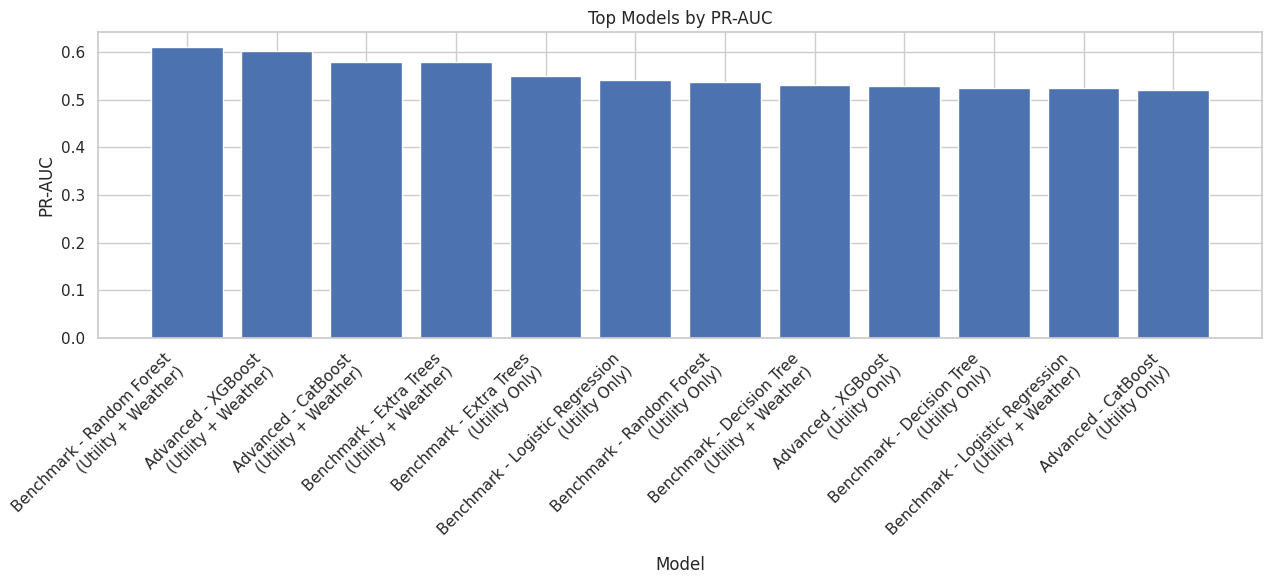

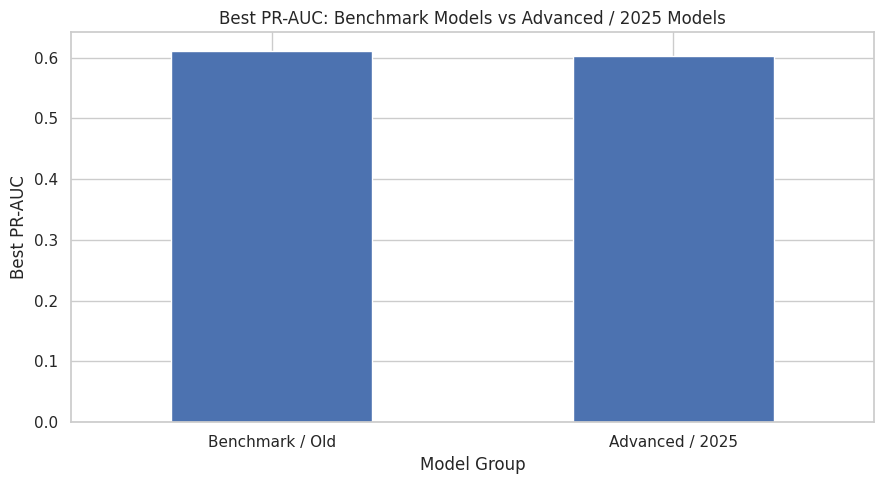

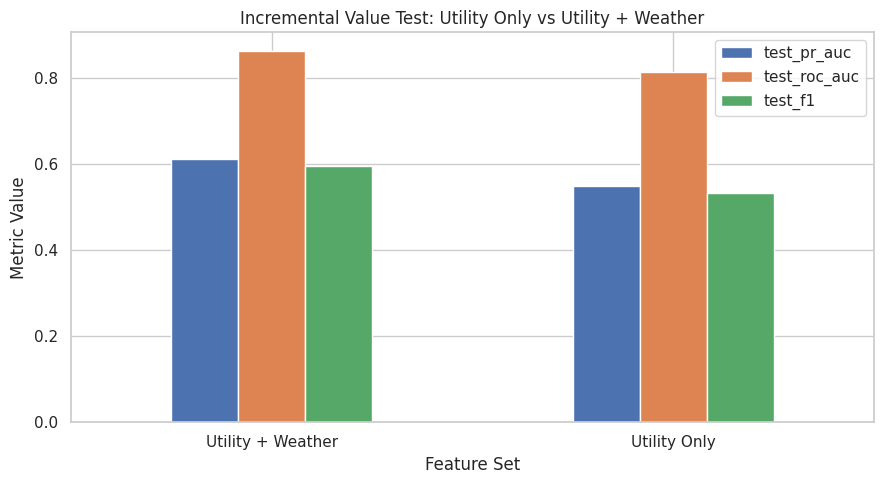

<Figure size 700x500 with 0 Axes>

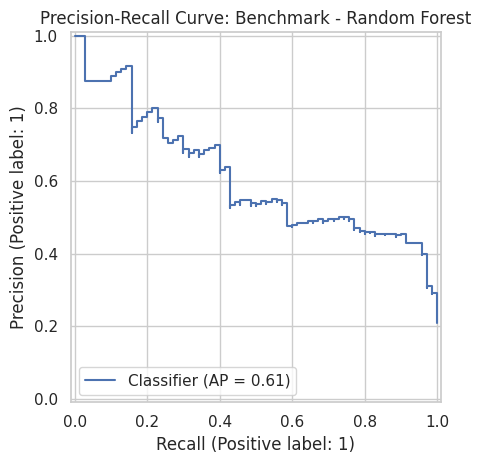

<Figure size 700x500 with 0 Axes>

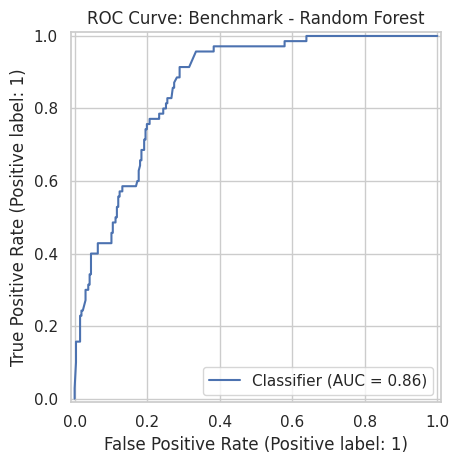

10321

In [5]:
# ============================================================
# CELL 3: ADVANCED MODELING + 2025 TABULAR MODELS
# Models:
# Benchmark: Logistic Regression, Decision Tree, Random Forest, Extra Trees
# Advanced: HistGradientBoosting, XGBoost, LightGBM, CatBoost
# 2025-style: TabPFN, Mambular, TabM, FTTransformer, Tangos
# ============================================================

# Run once in Colab if needed:
# !pip -q install xgboost lightgbm catboost tabpfn mambular

import os
import gc
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    PrecisionRecallDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

warnings.filterwarnings("ignore")

# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = "dashboard_clean_output/dashboard_clean_dataset.parquet"
OUTPUT_DIR = "optimized_modeling_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TOP_RISK_PERCENT = 0.20
TEST_SIZE = 0.20

# Deep-learning models can be slow. Keep epochs small for assignment/demo.
MAMBULAR_MAX_EPOCHS = 25
MAMBULAR_LR = 1e-4

# ============================================================
# OPTIONAL ADVANCED IMPORTS
# ============================================================

HAS_XGB = False
HAS_LGBM = False
HAS_CATBOOST = False
HAS_TABPFN = False
HAS_MAMBULAR_PACKAGE = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    print("XGBoost not available. Install with: !pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    print("LightGBM not available. Install with: !pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    print("CatBoost not available. Install with: !pip install catboost")

try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
except Exception:
    print("TabPFN not available. Install with: !pip install tabpfn")

try:
    import mambular.models as mb_models
    HAS_MAMBULAR_PACKAGE = True
except Exception:
    mb_models = None
    print("Mambular package not available. Install with: !pip install mambular")

# ============================================================
# WRAPPER FOR MAMBULAR-STYLE MODELS
# ============================================================

class MambularModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Small sklearn-compatible wrapper for mambular deep tabular models.
    This lets us use Mambular, TabM, FTTransformer, and Tangos inside sklearn Pipeline.
    """

    def __init__(self, model_class=None, max_epochs=25, lr=1e-4, random_state=42):
        self.model_class = model_class
        self.max_epochs = max_epochs
        self.lr = lr
        self.random_state = random_state
        self.model_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        if self.model_class is None:
            raise ValueError("Mambular model_class is None.")

        try:
            self.model_ = self.model_class(random_state=self.random_state)
        except Exception:
            try:
                self.model_ = self.model_class(seed=self.random_state)
            except Exception:
                self.model_ = self.model_class()

        try:
            self.model_.fit(X, y, max_epochs=self.max_epochs, lr=self.lr)
        except TypeError:
            try:
                self.model_.fit(X, y, max_epochs=self.max_epochs)
            except TypeError:
                self.model_.fit(X, y)

        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X))

    def predict_proba(self, X):
        if hasattr(self.model_, "predict_proba"):
            proba = self.model_.predict_proba(X)
            proba = np.asarray(proba)

            if proba.ndim == 1:
                proba = np.column_stack([1 - proba, proba])

            return proba

        pred = self.predict(X)
        proba = np.zeros((len(pred), 2))
        proba[:, 1] = pred
        proba[:, 0] = 1 - pred
        return proba

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=0.02,
            sparse_output=False
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=0.02,
                sparse=False
            )
        except TypeError:
            return OneHotEncoder(
                handle_unknown="ignore",
                sparse=False
            )

def safe_metric(metric_func, y_true, y_score_or_pred):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return metric_func(y_true, y_score_or_pred)
    except Exception:
        return np.nan

def get_pos_weight(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    return neg / max(pos, 1)

def get_numeric_series(df, col, default=0):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())
        ]), categorical_cols)
    ], remainder="drop")

    return preprocessor

def create_tabpfn_model():
    try:
        return TabPFNClassifier(random_state=RANDOM_STATE)
    except TypeError:
        return TabPFNClassifier()

def add_mambular_model_if_available(model_dict, model_name, class_name):
    if not HAS_MAMBULAR_PACKAGE:
        return

    model_class = getattr(mb_models, class_name, None)

    if model_class is not None:
        model_dict[model_name] = lambda spw, cls=model_class: MambularModelWrapper(
            model_class=cls,
            max_epochs=MAMBULAR_MAX_EPOCHS,
            lr=MAMBULAR_LR,
            random_state=RANDOM_STATE
        )

def make_model_factories():
    """
    Benchmark models = old/baseline models.
    Advanced models = stronger ML + 2025 tabular foundation/deep models.
    """

    benchmark_factories = {
        "Benchmark - Logistic Regression": lambda spw: LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE
        ),

        "Benchmark - Decision Tree": lambda spw: DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

        "Benchmark - Random Forest": lambda spw: RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

        "Benchmark - Extra Trees": lambda spw: ExtraTreesClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    }

    advanced_factories = {
        "Advanced - HistGradientBoosting": lambda spw: HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        )
    }

    if HAS_XGB:
        advanced_factories["Advanced - XGBoost"] = lambda spw: XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if HAS_LGBM:
        advanced_factories["Advanced - LightGBM"] = lambda spw: LGBMClassifier(
            n_estimators=350,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

    if HAS_CATBOOST:
        advanced_factories["Advanced - CatBoost"] = lambda spw: CatBoostClassifier(
            iterations=350,
            depth=5,
            learning_rate=0.04,
            loss_function="Logloss",
            eval_metric="AUC",
            scale_pos_weight=spw,
            random_seed=RANDOM_STATE,
            verbose=False
        )

    if HAS_TABPFN:
        advanced_factories["Advanced 2025 - TabPFN"] = lambda spw: create_tabpfn_model()

    # 2025-style tabular deep learning models from mambular package
    add_mambular_model_if_available(
        advanced_factories,
        "Advanced 2025 - Mambular",
        "MambularClassifier"
    )

    add_mambular_model_if_available(
        advanced_factories,
        "Advanced 2025 - TabM",
        "TabMClassifier"
    )

    add_mambular_model_if_available(
        advanced_factories,
        "Advanced 2025 - FTTransformer",
        "FTTransformerClassifier"
    )

    add_mambular_model_if_available(
        advanced_factories,
        "Advanced 2025 - Tangos",
        "TangosClassifier"
    )

    return benchmark_factories, advanced_factories

# ============================================================
# LOAD DATA
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH).copy()
print("Loaded shape:", df.shape)

if "Data Year" in df.columns:
    df["Data Year"] = pd.to_numeric(df["Data Year"], errors="coerce")
    df = df[df["Data Year"] == 2024].copy()

for c in df.columns:
    if str(df[c].dtype) == "category":
        df[c] = df[c].astype("object")

# ============================================================
# CLEAN NUMERIC FIELDS
# ============================================================

numeric_candidates = [
    "Utility Number",
    "County_Count",
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "IEEE_NoMED_SAIDI_min_per_yr",
    "IEEE_NoMED_SAIFI_times_per_yr",
    "IEEE_NoMED_CAIDI_min_per_interruption",
    "MAGNITUDE",
    "DAMAGE_PROPERTY_USD",
    "DAMAGE_CROPS_USD",
    "total_damage_usd",
    "log_total_damage",
    "INJURIES_DIRECT",
    "INJURIES_INDIRECT",
    "DEATHS_DIRECT",
    "DEATHS_INDIRECT",
    "total_injuries",
    "total_deaths",
    "human_impact_score",
    "BEGIN_MONTH"
]

for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "total_damage_usd" not in df.columns:
    prop = get_numeric_series(df, "DAMAGE_PROPERTY_USD", 0).fillna(0)
    crop = get_numeric_series(df, "DAMAGE_CROPS_USD", 0).fillna(0)
    df["total_damage_usd"] = prop + crop

if "log_total_damage" not in df.columns:
    df["log_total_damage"] = np.log1p(df["total_damage_usd"].fillna(0))

if "total_injuries" not in df.columns:
    df["total_injuries"] = (
        get_numeric_series(df, "INJURIES_DIRECT", 0).fillna(0) +
        get_numeric_series(df, "INJURIES_INDIRECT", 0).fillna(0)
    )

if "total_deaths" not in df.columns:
    df["total_deaths"] = (
        get_numeric_series(df, "DEATHS_DIRECT", 0).fillna(0) +
        get_numeric_series(df, "DEATHS_INDIRECT", 0).fillna(0)
    )

if "human_impact_score" not in df.columns:
    df["human_impact_score"] = df["total_injuries"].fillna(0) + 5 * df["total_deaths"].fillna(0)

# ============================================================
# TARGET CREATION BEFORE AGGREGATION
# ============================================================

target_cols = [
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr"
]

df = df.dropna(subset=target_cols).copy()

df["saidi_rank_pct"] = df["IEEE_AllEvents_SAIDI_min_per_yr"].rank(pct=True)
df["saifi_rank_pct"] = df["IEEE_AllEvents_SAIFI_times_per_yr"].rank(pct=True)

df["composite_outage_risk_score"] = (
    df["saidi_rank_pct"] + df["saifi_rank_pct"]
) / 2

# ============================================================
# AGGREGATE TO ONE ROW PER UTILITY
# ============================================================

group_key = "Utility Number"

if group_key not in df.columns:
    raise ValueError("Utility Number column is required for utility-level modeling.")

static_cat_cols = [
    c for c in ["Utility Name", "State", "Ownership", "NERC Region"]
    if c in df.columns
]

binary_cols = [
    c for c in [
        "TRE", "FRCC", "MRO", "NPCC", "RFC", "SERC", "SPP", "WECC",
        "CAISO", "ERCOT", "PJM", "NYISO", "SPP.1", "MISO", "ISONE",
        "Generation", "Transmission", "Buying Transmission", "Distribution",
        "Buying Distribution", "Wholesale Marketing", "Retail Marketing",
        "Bundled"
    ]
    if c in df.columns
]

agg_dict = {
    "IEEE_AllEvents_SAIDI_min_per_yr": "mean",
    "IEEE_AllEvents_SAIFI_times_per_yr": "mean"
}

optional_mean_cols = [
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "IEEE_NoMED_SAIDI_min_per_yr",
    "IEEE_NoMED_SAIFI_times_per_yr",
    "IEEE_NoMED_CAIDI_min_per_interruption",
    "MAGNITUDE"
]

for c in optional_mean_cols:
    if c in df.columns:
        agg_dict[c] = "mean"

for c in binary_cols:
    agg_dict[c] = "max"

if "County_Count" in df.columns:
    agg_dict["County_Count"] = "max"

sum_weather_cols = [
    "total_damage_usd",
    "total_injuries",
    "total_deaths",
    "human_impact_score"
]

for c in sum_weather_cols:
    if c in df.columns:
        agg_dict[c] = "sum"

utility_df = df.groupby(group_key, as_index=False).agg(agg_dict)

if "total_damage_usd" in utility_df.columns:
    utility_df["log_total_damage"] = np.log1p(utility_df["total_damage_usd"].fillna(0))

if "MAGNITUDE" in df.columns:
    max_mag = df.groupby(group_key)["MAGNITUDE"].max().reset_index(name="max_magnitude")
    utility_df = utility_df.merge(max_mag, on=group_key, how="left")

for c in static_cat_cols:
    tmp = (
        df.groupby(group_key)[c]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        .reset_index()
    )
    utility_df = utility_df.merge(tmp, on=group_key, how="left")

if "EVENT_TYPE" in df.columns:
    tmp = df.groupby(group_key)["EVENT_TYPE"].nunique().reset_index(name="unique_event_types")
    utility_df = utility_df.merge(tmp, on=group_key, how="left")

if "BEGIN_MONTH" in df.columns:
    tmp = df.groupby(group_key)["BEGIN_MONTH"].nunique().reset_index(name="months_with_events")
    utility_df = utility_df.merge(tmp, on=group_key, how="left")

if "EVENT_ID" in df.columns:
    tmp = df.groupby(group_key)["EVENT_ID"].nunique().reset_index(name="weather_event_count")
else:
    tmp = df.groupby(group_key).size().reset_index(name="weather_event_count")

utility_df = utility_df.merge(tmp, on=group_key, how="left")

if "EPISODE_ID" in df.columns:
    tmp = df.groupby(group_key)["EPISODE_ID"].nunique().reset_index(name="storm_episode_count")
    utility_df = utility_df.merge(tmp, on=group_key, how="left")

if "CZ_NAME" in df.columns:
    tmp = df.groupby(group_key)["CZ_NAME"].nunique().reset_index(name="unique_counties_hit")
    utility_df = utility_df.merge(tmp, on=group_key, how="left")

print("Utility-level modeling shape:", utility_df.shape)

# ============================================================
# REBUILD UTILITY-LEVEL LABEL
# ============================================================

utility_df["saidi_rank_pct"] = utility_df["IEEE_AllEvents_SAIDI_min_per_yr"].rank(pct=True)
utility_df["saifi_rank_pct"] = utility_df["IEEE_AllEvents_SAIFI_times_per_yr"].rank(pct=True)

utility_df["composite_outage_risk_score"] = (
    utility_df["saidi_rank_pct"] + utility_df["saifi_rank_pct"]
) / 2

thr_utility = utility_df["composite_outage_risk_score"].quantile(1 - TOP_RISK_PERCENT)

utility_df["high_risk"] = (
    utility_df["composite_outage_risk_score"] >= thr_utility
).astype(int)

# ============================================================
# CLASS BALANCE REPORT
# ============================================================

summary_df = pd.DataFrame({
    "item": [
        "time_range_used",
        "dataset_rows_after_utility_aggregation",
        "unique_utilities",
        "high_risk_count",
        "low_risk_count",
        "high_risk_percent",
        "label_definition",
        "threshold_value"
    ],
    "value": [
        "2024 only",
        len(utility_df),
        utility_df[group_key].nunique(),
        int(utility_df["high_risk"].sum()),
        int((utility_df["high_risk"] == 0).sum()),
        round(100 * utility_df["high_risk"].mean(), 2),
        "Top 20% by average percentile rank of SAIDI and SAIFI",
        round(float(thr_utility), 6)
    ]
})

summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "project_scope_and_class_balance.csv"),
    index=False
)

print("\n===== PROJECT SCOPE AND CLASS BALANCE =====")
print(summary_df)

# ============================================================
# FEATURE SETS
# ============================================================

leakage_cols = [
    "high_risk",
    "saidi_rank_pct",
    "saifi_rank_pct",
    "composite_outage_risk_score",
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "IEEE_NoMED_SAIDI_min_per_yr",
    "IEEE_NoMED_SAIFI_times_per_yr",
    "IEEE_NoMED_CAIDI_min_per_interruption",
    "Utility Number",
    "Utility Name"
]

all_candidate_features = [
    c for c in utility_df.columns
    if c not in leakage_cols
]

weather_feature_names = {
    "total_damage_usd",
    "log_total_damage",
    "total_injuries",
    "total_deaths",
    "human_impact_score",
    "MAGNITUDE",
    "max_magnitude",
    "unique_event_types",
    "months_with_events",
    "weather_event_count",
    "storm_episode_count",
    "unique_counties_hit"
}

utility_only_features = [
    c for c in all_candidate_features
    if c not in weather_feature_names
]

utility_weather_features = all_candidate_features.copy()

print("\nUtility-only feature count:", len(utility_only_features))
print("Utility + Weather feature count:", len(utility_weather_features))

utility_df.to_csv(
    os.path.join(OUTPUT_DIR, "utility_level_modeling_dataset.csv"),
    index=False
)

# ============================================================
# MODEL SETUP
# ============================================================

benchmark_factories, advanced_factories = make_model_factories()

model_availability = pd.DataFrame({
    "model_group": (
        ["Benchmark / Old"] * len(benchmark_factories) +
        ["Advanced / 2025"] * len(advanced_factories)
    ),
    "model": list(benchmark_factories.keys()) + list(advanced_factories.keys())
})

model_availability.to_csv(
    os.path.join(OUTPUT_DIR, "model_availability.csv"),
    index=False
)

print("\n===== MODELS INCLUDED =====")
print(model_availability)

all_model_factories = {}
all_model_factories.update({
    name: ("Benchmark / Old", factory)
    for name, factory in benchmark_factories.items()
})
all_model_factories.update({
    name: ("Advanced / 2025", factory)
    for name, factory in advanced_factories.items()
})

# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_feature_set(df_in, feature_cols, set_name):
    X = df_in[feature_cols].copy()
    y = df_in["high_risk"].copy()

    train_idx, test_idx = train_test_split(
        df_in.index,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    X_train = X.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_train = y.loc[train_idx].copy()
    y_test = y.loc[test_idx].copy()

    pos_weight = get_pos_weight(y_train)

    results = []
    trained_objects = {}

    metadata_cols = [
        c for c in [
            "Utility Number", "Utility Name", "State", "Ownership", "NERC Region",
            "County_Count", "weather_event_count", "storm_episode_count",
            "unique_event_types", "unique_counties_hit", "months_with_events",
            "total_damage_usd", "log_total_damage", "total_injuries",
            "total_deaths", "human_impact_score", "MAGNITUDE", "max_magnitude",
            "IEEE_AllEvents_SAIDI_min_per_yr",
            "IEEE_AllEvents_SAIFI_times_per_yr",
            "composite_outage_risk_score"
        ]
        if c in df_in.columns
    ]

    for model_name, (model_group, factory) in all_model_factories.items():
        try:
            preprocessor = build_preprocessor(X_train)
            model = factory(pos_weight)

            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            proba = pipe.predict_proba(X_test)[:, 1]
            pred = (proba >= 0.50).astype(int)

            row = {
                "feature_set": set_name,
                "model_group": model_group,
                "model": model_name,
                "model_status": "success",
                "error_message": "",
                "test_accuracy": accuracy_score(y_test, pred),
                "test_precision": precision_score(y_test, pred, zero_division=0),
                "test_recall": recall_score(y_test, pred, zero_division=0),
                "test_f1": f1_score(y_test, pred, zero_division=0),
                "test_roc_auc": safe_metric(roc_auc_score, y_test, proba),
                "test_pr_auc": safe_metric(average_precision_score, y_test, proba),
                "test_confusion_matrix": confusion_matrix(y_test, pred).tolist()
            }

            results.append(row)

            pred_frame = df_in.loc[test_idx, metadata_cols].copy()
            pred_frame["feature_set"] = set_name
            pred_frame["model_group"] = model_group
            pred_frame["model"] = model_name
            pred_frame["actual_high_risk"] = y_test.values
            pred_frame["predicted_high_risk"] = pred
            pred_frame["predicted_probability"] = proba

            trained_objects[(set_name, model_name)] = {
                "pipeline": pipe,
                "X_test": X_test.copy(),
                "y_test": y_test.copy(),
                "proba": proba.copy(),
                "pred": pred.copy(),
                "feature_cols": feature_cols,
                "pred_frame": pred_frame
            }

            print(f"Done: {set_name} | {model_group} | {model_name}")

        except Exception as e:
            print(f"Skipped: {set_name} | {model_group} | {model_name} | Error: {e}")

            results.append({
                "feature_set": set_name,
                "model_group": model_group,
                "model": model_name,
                "model_status": "failed",
                "error_message": str(e),
                "test_accuracy": np.nan,
                "test_precision": np.nan,
                "test_recall": np.nan,
                "test_f1": np.nan,
                "test_roc_auc": np.nan,
                "test_pr_auc": np.nan,
                "test_confusion_matrix": None
            })

    result_df = pd.DataFrame(results).sort_values(
        by=["test_pr_auc", "test_roc_auc", "test_f1"],
        ascending=False,
        na_position="last"
    ).reset_index(drop=True)

    return result_df, trained_objects

# ============================================================
# RUN FEATURE SET COMPARISON
# ============================================================

utility_results, utility_objs = evaluate_feature_set(
    utility_df,
    utility_only_features,
    "Utility Only"
)

weather_results, weather_objs = evaluate_feature_set(
    utility_df,
    utility_weather_features,
    "Utility + Weather"
)

all_results = pd.concat([utility_results, weather_results], ignore_index=True)

all_results = all_results.sort_values(
    by=["test_pr_auc", "test_roc_auc", "test_f1"],
    ascending=False,
    na_position="last"
).reset_index(drop=True)

all_results.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison_all.csv"),
    index=False
)

print("\n===== MODEL RESULTS =====")
print(all_results.round(4))

success_results = all_results[all_results["model_status"] == "success"].copy()

if success_results.empty:
    raise ValueError("No model trained successfully. Check package installation and data format.")

# ============================================================
# BENCHMARK VS ADVANCED SUMMARY
# ============================================================

group_summary = (
    success_results
    .groupby(["model_group", "feature_set"])
    .agg(
        best_pr_auc=("test_pr_auc", "max"),
        avg_pr_auc=("test_pr_auc", "mean"),
        best_roc_auc=("test_roc_auc", "max"),
        avg_roc_auc=("test_roc_auc", "mean"),
        best_f1=("test_f1", "max"),
        avg_f1=("test_f1", "mean")
    )
    .reset_index()
)

group_summary.to_csv(
    os.path.join(OUTPUT_DIR, "benchmark_vs_advanced_summary.csv"),
    index=False
)

print("\n===== BENCHMARK VS ADVANCED SUMMARY =====")
print(group_summary.round(4))

# ============================================================
# INCREMENTAL VALUE TEST
# ============================================================

best_by_feature_set = (
    success_results
    .sort_values(by=["test_pr_auc", "test_roc_auc", "test_f1"], ascending=False)
    .groupby("feature_set")
    .head(1)
    .reset_index(drop=True)
)

best_by_feature_set.to_csv(
    os.path.join(OUTPUT_DIR, "incremental_value_test.csv"),
    index=False
)

print("\n===== INCREMENTAL VALUE TEST =====")
print(best_by_feature_set.round(4))

# ============================================================
# SAVE BEST MODEL TEST PREDICTIONS
# ============================================================

all_trained = {}
all_trained.update(utility_objs)
all_trained.update(weather_objs)

best_row = success_results.iloc[0]
best_key = (best_row["feature_set"], best_row["model"])

best_obj = all_trained[best_key]
best_pred_df = best_obj["pred_frame"].copy()

best_pred_df.to_csv(
    os.path.join(OUTPUT_DIR, "best_model_test_predictions.csv"),
    index=False
)

best_metadata = {
    "best_feature_set": best_row["feature_set"],
    "best_model_group": best_row["model_group"],
    "best_model": best_row["model"],
    "best_pr_auc": float(best_row["test_pr_auc"]),
    "best_roc_auc": float(best_row["test_roc_auc"]),
    "best_f1": float(best_row["test_f1"]),
    "label_definition": "Top 20% by average percentile rank of SAIDI and SAIFI",
    "threshold_value": float(thr_utility)
}

with open(os.path.join(OUTPUT_DIR, "best_model_metadata.json"), "w") as f:
    json.dump(best_metadata, f, indent=4)

print("\n===== BEST MODEL =====")
print(best_metadata)

print("\nSaved files:")
print("- utility_level_modeling_dataset.csv")
print("- project_scope_and_class_balance.csv")
print("- model_availability.csv")
print("- model_comparison_all.csv")
print("- benchmark_vs_advanced_summary.csv")
print("- incremental_value_test.csv")
print("- best_model_test_predictions.csv")
print("- best_model_metadata.json")

# ============================================================
# VISUALS
# ============================================================

top_plot = success_results.sort_values("test_pr_auc", ascending=False).head(12).copy()
top_plot["label"] = top_plot["model"] + "\n(" + top_plot["feature_set"] + ")"

plt.figure(figsize=(13, 6))
plt.bar(top_plot["label"], top_plot["test_pr_auc"])
plt.title("Top Models by PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
group_plot = (
    success_results
    .groupby("model_group")["test_pr_auc"]
    .max()
    .sort_values(ascending=False)
)
group_plot.plot(kind="bar")
plt.title("Best PR-AUC: Benchmark Models vs Advanced / 2025 Models")
plt.xlabel("Model Group")
plt.ylabel("Best PR-AUC")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_by_feature_set.set_index("feature_set")[["test_pr_auc", "test_roc_auc", "test_f1"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Incremental Value Test: Utility Only vs Utility + Weather")
plt.xlabel("Feature Set")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_y_test = best_obj["y_test"]
best_proba = best_obj["proba"]

plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(best_y_test, best_proba)
plt.title(f"Precision-Recall Curve: {best_row['model']}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(best_y_test, best_proba)
plt.title(f"ROC Curve: {best_row['model']}")
plt.tight_layout()
plt.show()

gc.collect()

Predictions shape: (336, 25)
Utility-level dataset shape: (1677, 49)

===== ERROR SUMMARY =====
       error_type  count
0   True Negative    209
1  False Positive     57
2   True Positive     54
3  False Negative     16

===== ERROR GROUP CHARACTERISTICS =====
                County_Count  weather_event_count  unique_event_types  \
error_type                                                              
False Negative         3.000              936.500              20.562   
False Positive         7.737             1274.263              21.351   
True Negative          5.129             1284.622              22.000   
True Positive         12.537             1013.000              19.963   

                months_with_events  total_damage_usd  log_total_damage  \
error_type                                                               
False Negative              12.000      2.070758e+08            18.738   
False Positive              11.860      6.324960e+08            19.264   
Tru

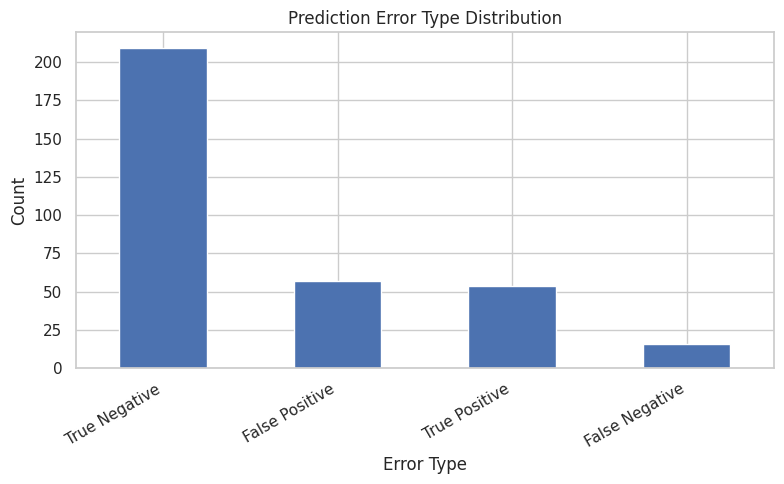

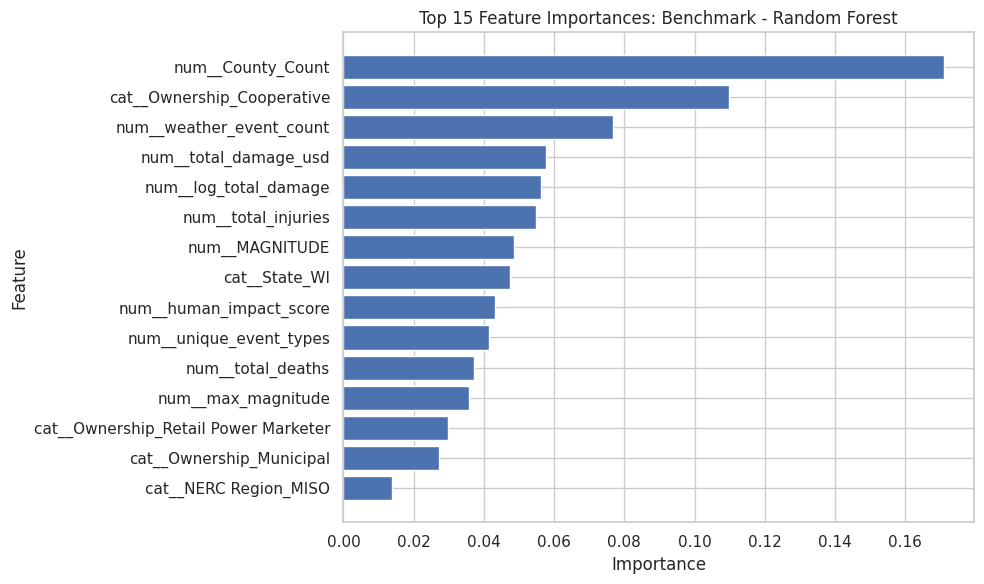

<Figure size 800x500 with 0 Axes>

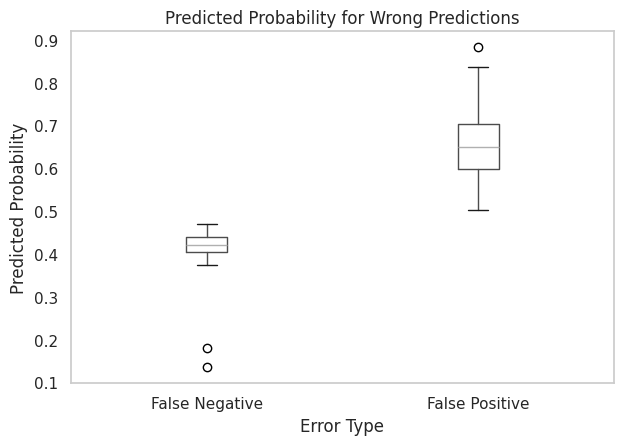

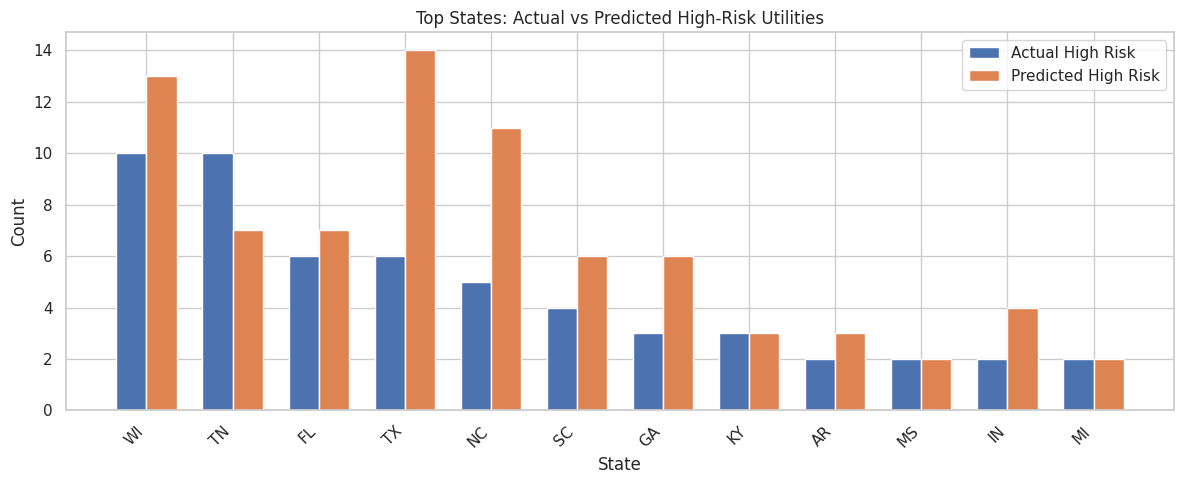

13196

In [6]:
# ============================================================
# CELL 4: ERROR ANALYSIS + FEATURE IMPORTANCE
# Works with advanced 2025 models from Cell 3
# ============================================================

# Run once in Colab if needed:
# !pip -q install xgboost lightgbm catboost tabpfn mambular

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

warnings.filterwarnings("ignore")

# ============================================================
# SETTINGS
# ============================================================

OUTPUT_DIR = "optimized_modeling_outputs"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAMBULAR_MAX_EPOCHS = 25
MAMBULAR_LR = 1e-4

pred_path = os.path.join(OUTPUT_DIR, "best_model_test_predictions.csv")
model_results_path = os.path.join(OUTPUT_DIR, "model_comparison_all.csv")
utility_data_path = os.path.join(OUTPUT_DIR, "utility_level_modeling_dataset.csv")

if not os.path.exists(pred_path):
    raise FileNotFoundError("Run Cell 3 first: best_model_test_predictions.csv not found")
if not os.path.exists(model_results_path):
    raise FileNotFoundError("Run Cell 3 first: model_comparison_all.csv not found")
if not os.path.exists(utility_data_path):
    raise FileNotFoundError("Run Cell 3 first: utility_level_modeling_dataset.csv not found")

# ============================================================
# OPTIONAL IMPORTS
# ============================================================

HAS_XGB = False
HAS_LGBM = False
HAS_CATBOOST = False
HAS_TABPFN = False
HAS_MAMBULAR_PACKAGE = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    pass

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    pass

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    pass

try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
except Exception:
    pass

try:
    import mambular.models as mb_models
    HAS_MAMBULAR_PACKAGE = True
except Exception:
    mb_models = None

# ============================================================
# WRAPPER
# ============================================================

class MambularModelWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_class=None, max_epochs=25, lr=1e-4, random_state=42):
        self.model_class = model_class
        self.max_epochs = max_epochs
        self.lr = lr
        self.random_state = random_state
        self.model_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        if self.model_class is None:
            raise ValueError("Mambular model_class is None.")

        try:
            self.model_ = self.model_class(random_state=self.random_state)
        except Exception:
            try:
                self.model_ = self.model_class(seed=self.random_state)
            except Exception:
                self.model_ = self.model_class()

        try:
            self.model_.fit(X, y, max_epochs=self.max_epochs, lr=self.lr)
        except TypeError:
            try:
                self.model_.fit(X, y, max_epochs=self.max_epochs)
            except TypeError:
                self.model_.fit(X, y)

        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X))

    def predict_proba(self, X):
        if hasattr(self.model_, "predict_proba"):
            proba = np.asarray(self.model_.predict_proba(X))
            if proba.ndim == 1:
                proba = np.column_stack([1 - proba, proba])
            return proba

        pred = self.predict(X)
        proba = np.zeros((len(pred), 2))
        proba[:, 1] = pred
        proba[:, 0] = 1 - pred
        return proba

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=0.02,
            sparse_output=False
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=0.02,
                sparse=False
            )
        except TypeError:
            return OneHotEncoder(
                handle_unknown="ignore",
                sparse=False
            )

def get_pos_weight(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    return neg / max(pos, 1)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())
        ]), categorical_cols)
    ], remainder="drop")

    return preprocessor

def create_tabpfn_model():
    try:
        return TabPFNClassifier(random_state=RANDOM_STATE)
    except TypeError:
        return TabPFNClassifier()

def add_mambular_model_if_available(model_dict, model_name, class_name):
    if not HAS_MAMBULAR_PACKAGE:
        return

    model_class = getattr(mb_models, class_name, None)

    if model_class is not None:
        model_dict[model_name] = lambda spw, cls=model_class: MambularModelWrapper(
            model_class=cls,
            max_epochs=MAMBULAR_MAX_EPOCHS,
            lr=MAMBULAR_LR,
            random_state=RANDOM_STATE
        )

def make_model_factories():
    factories = {
        "Benchmark - Logistic Regression": lambda spw: LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE
        ),

        "Benchmark - Decision Tree": lambda spw: DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

        "Benchmark - Random Forest": lambda spw: RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

        "Benchmark - Extra Trees": lambda spw: ExtraTreesClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

        "Advanced - HistGradientBoosting": lambda spw: HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        )
    }

    if HAS_XGB:
        factories["Advanced - XGBoost"] = lambda spw: XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if HAS_LGBM:
        factories["Advanced - LightGBM"] = lambda spw: LGBMClassifier(
            n_estimators=350,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

    if HAS_CATBOOST:
        factories["Advanced - CatBoost"] = lambda spw: CatBoostClassifier(
            iterations=350,
            depth=5,
            learning_rate=0.04,
            loss_function="Logloss",
            eval_metric="AUC",
            scale_pos_weight=spw,
            random_seed=RANDOM_STATE,
            verbose=False
        )

    if HAS_TABPFN:
        factories["Advanced 2025 - TabPFN"] = lambda spw: create_tabpfn_model()

    add_mambular_model_if_available(factories, "Advanced 2025 - Mambular", "MambularClassifier")
    add_mambular_model_if_available(factories, "Advanced 2025 - TabM", "TabMClassifier")
    add_mambular_model_if_available(factories, "Advanced 2025 - FTTransformer", "FTTransformerClassifier")
    add_mambular_model_if_available(factories, "Advanced 2025 - Tangos", "TangosClassifier")

    return factories

# ============================================================
# LOAD FILES
# ============================================================

pred_df = pd.read_csv(pred_path)
results_df = pd.read_csv(model_results_path)
utility_df = pd.read_csv(utility_data_path)

print("Predictions shape:", pred_df.shape)
print("Utility-level dataset shape:", utility_df.shape)

success_results = results_df[results_df["model_status"] == "success"].copy()

if success_results.empty:
    raise ValueError("No successful models found from Cell 3.")

# ============================================================
# ERROR LABELS
# ============================================================

pred_df["error_type"] = np.select(
    [
        (pred_df["actual_high_risk"] == 1) & (pred_df["predicted_high_risk"] == 1),
        (pred_df["actual_high_risk"] == 0) & (pred_df["predicted_high_risk"] == 0),
        (pred_df["actual_high_risk"] == 0) & (pred_df["predicted_high_risk"] == 1),
        (pred_df["actual_high_risk"] == 1) & (pred_df["predicted_high_risk"] == 0),
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

error_summary = pred_df["error_type"].value_counts().reset_index()
error_summary.columns = ["error_type", "count"]

error_summary.to_csv(
    os.path.join(OUTPUT_DIR, "error_summary.csv"),
    index=False
)

print("\n===== ERROR SUMMARY =====")
print(error_summary)

# ============================================================
# SAVE FALSE POSITIVES / FALSE NEGATIVES
# ============================================================

important_cols = [
    c for c in [
        "Utility Number", "Utility Name", "State", "Ownership", "NERC Region",
        "County_Count", "weather_event_count", "storm_episode_count",
        "unique_event_types", "unique_counties_hit", "months_with_events",
        "total_damage_usd", "log_total_damage", "total_injuries", "total_deaths",
        "human_impact_score", "MAGNITUDE", "max_magnitude",
        "IEEE_AllEvents_SAIDI_min_per_yr",
        "IEEE_AllEvents_SAIFI_times_per_yr",
        "composite_outage_risk_score",
        "feature_set", "model_group", "model",
        "actual_high_risk", "predicted_high_risk",
        "predicted_probability", "error_type"
    ]
    if c in pred_df.columns
]

fp_df = pred_df[pred_df["error_type"] == "False Positive"].copy()
fn_df = pred_df[pred_df["error_type"] == "False Negative"].copy()

fp_df[important_cols].to_csv(
    os.path.join(OUTPUT_DIR, "false_positives.csv"),
    index=False
)

fn_df[important_cols].to_csv(
    os.path.join(OUTPUT_DIR, "false_negatives.csv"),
    index=False
)

# ============================================================
# ERROR GROUP CHARACTERISTICS
# ============================================================

numeric_compare_cols = [
    c for c in [
        "County_Count", "weather_event_count", "storm_episode_count",
        "unique_event_types", "unique_counties_hit", "months_with_events",
        "total_damage_usd", "log_total_damage", "total_injuries", "total_deaths",
        "human_impact_score", "MAGNITUDE", "max_magnitude",
        "IEEE_AllEvents_SAIDI_min_per_yr",
        "IEEE_AllEvents_SAIFI_times_per_yr",
        "composite_outage_risk_score",
        "predicted_probability"
    ]
    if c in pred_df.columns
]

if numeric_compare_cols:
    error_group_profile = (
        pred_df
        .groupby("error_type")[numeric_compare_cols]
        .mean()
        .round(3)
    )

    error_group_profile.to_csv(
        os.path.join(OUTPUT_DIR, "error_group_characteristics.csv")
    )

    print("\n===== ERROR GROUP CHARACTERISTICS =====")
    print(error_group_profile)

# ============================================================
# STATE BREAKDOWN
# ============================================================

if "State" in pred_df.columns:
    state_breakdown = (
        pred_df
        .groupby("State")
        .agg(
            utility_count=("Utility Number", "nunique") if "Utility Number" in pred_df.columns else ("State", "size"),
            records=("State", "size"),
            actual_high_risk=("actual_high_risk", "sum"),
            predicted_high_risk=("predicted_high_risk", "sum"),
            false_positives=("error_type", lambda s: (s == "False Positive").sum()),
            false_negatives=("error_type", lambda s: (s == "False Negative").sum()),
            avg_predicted_probability=("predicted_probability", "mean")
        )
        .reset_index()
        .sort_values(
            ["actual_high_risk", "avg_predicted_probability"],
            ascending=[False, False]
        )
    )

    state_breakdown.to_csv(
        os.path.join(OUTPUT_DIR, "state_risk_breakdown.csv"),
        index=False
    )

    print("\n===== TOP STATE BREAKDOWN =====")
    print(state_breakdown.head(15))

# ============================================================
# REBUILD BEST MODEL FOR FEATURE IMPORTANCE
# ============================================================

best_row = success_results.sort_values(
    by=["test_pr_auc", "test_roc_auc", "test_f1"],
    ascending=False
).iloc[0]

best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_model_group = best_row["model_group"]

print("\nBest feature set:", best_feature_set)
print("Best model group:", best_model_group)
print("Best model:", best_model_name)

leakage_cols = [
    "high_risk",
    "saidi_rank_pct",
    "saifi_rank_pct",
    "composite_outage_risk_score",
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "IEEE_NoMED_SAIDI_min_per_yr",
    "IEEE_NoMED_SAIFI_times_per_yr",
    "IEEE_NoMED_CAIDI_min_per_interruption",
    "Utility Number",
    "Utility Name"
]

weather_feature_names = {
    "total_damage_usd",
    "log_total_damage",
    "total_injuries",
    "total_deaths",
    "human_impact_score",
    "MAGNITUDE",
    "max_magnitude",
    "unique_event_types",
    "months_with_events",
    "weather_event_count",
    "storm_episode_count",
    "unique_counties_hit"
}

all_candidate_features = [
    c for c in utility_df.columns
    if c not in leakage_cols
]

if best_feature_set == "Utility Only":
    feature_cols = [
        c for c in all_candidate_features
        if c not in weather_feature_names
    ]
else:
    feature_cols = all_candidate_features.copy()

X = utility_df[feature_cols].copy()
y = utility_df["high_risk"].copy()

train_idx, test_idx = train_test_split(
    utility_df.index,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

pos_weight = get_pos_weight(y_train)

model_factories = make_model_factories()

if best_model_name not in model_factories:
    raise ValueError(
        f"{best_model_name} is not available in this environment. "
        "Install the needed package and rerun Cell 3 and Cell 4."
    )

preprocessor = build_preprocessor(X_train)
best_model = model_factories[best_model_name](pos_weight)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", best_model)
])

pipe.fit(X_train, y_train)

prep = pipe.named_steps["prep"]
model = pipe.named_steps["model"]

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

try:
    transformed_names = prep.get_feature_names_out()
except Exception:
    transformed_names = [
        f"feature_{i}"
        for i in range(prep.transform(X_train.head(5)).shape[1])
    ]

if hasattr(model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": transformed_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

elif hasattr(model, "coef_"):
    coef_vals = np.abs(model.coef_[0])
    feature_importance_df = pd.DataFrame({
        "feature": transformed_names,
        "importance": coef_vals
    }).sort_values("importance", ascending=False)

else:
    sample_n = min(300, len(X_test))
    X_test_sample = X_test.sample(sample_n, random_state=RANDOM_STATE)
    y_test_sample = y_test.loc[X_test_sample.index]

    perm = permutation_importance(
        pipe,
        X_test_sample,
        y_test_sample,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="average_precision"
    )

    feature_importance_df = pd.DataFrame({
        "feature": X_test_sample.columns,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False)

feature_importance_df = feature_importance_df.reset_index(drop=True)

feature_importance_df.to_csv(
    os.path.join(OUTPUT_DIR, "top_feature_importance.csv"),
    index=False
)

print("\n===== TOP FEATURE IMPORTANCE =====")
print(feature_importance_df.head(20))

print("\nSaved files:")
print("- error_summary.csv")
print("- false_positives.csv")
print("- false_negatives.csv")
print("- error_group_characteristics.csv")
print("- state_risk_breakdown.csv")
print("- top_feature_importance.csv")

# ============================================================
# VISUALS
# ============================================================

plt.figure(figsize=(8, 5))
error_summary.set_index("error_type")["count"].plot(kind="bar")
plt.title("Prediction Error Type Distribution")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

top_feat = feature_importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_feat["feature"], top_feat["importance"])
plt.title(f"Top 15 Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

error_prob_df = pred_df[
    pred_df["error_type"].isin(["False Positive", "False Negative"])
].copy()

if len(error_prob_df) > 0:
    plt.figure(figsize=(8, 5))
    error_prob_df.boxplot(
        column="predicted_probability",
        by="error_type",
        grid=False
    )
    plt.title("Predicted Probability for Wrong Predictions")
    plt.suptitle("")
    plt.xlabel("Error Type")
    plt.ylabel("Predicted Probability")
    plt.tight_layout()
    plt.show()

if "State" in pred_df.columns:
    state_plot = state_breakdown.head(12).copy()

    x = np.arange(len(state_plot))
    width = 0.35

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, state_plot["actual_high_risk"], width, label="Actual High Risk")
    plt.bar(x + width / 2, state_plot["predicted_high_risk"], width, label="Predicted High Risk")
    plt.xticks(x, state_plot["State"], rotation=45, ha="right")
    plt.title("Top States: Actual vs Predicted High-Risk Utilities")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

gc.collect()

Mambular package not available. Install with: !pip install mambular
Loaded utility-level dataset: (1677, 49)

Models included in sensitivity check:
- Benchmark / Old: Benchmark - Logistic Regression
- Benchmark / Old: Benchmark - Decision Tree
- Benchmark / Old: Benchmark - Random Forest
- Benchmark / Old: Benchmark - Extra Trees
- Advanced / 2025: Advanced - HistGradientBoosting
- Advanced / 2025: Advanced - XGBoost
- Advanced / 2025: Advanced - LightGBM
- Advanced / 2025: Advanced - CatBoost
- Advanced / 2025: Advanced 2025 - TabPFN
Done: Top 10% | Utility Only | Benchmark / Old | Benchmark - Logistic Regression
Done: Top 10% | Utility Only | Benchmark / Old | Benchmark - Decision Tree
Done: Top 10% | Utility Only | Benchmark / Old | Benchmark - Random Forest
Done: Top 10% | Utility Only | Benchmark / Old | Benchmark - Extra Trees
Done: Top 10% | Utility Only | Advanced / 2025 | Advanced - HistGradientBoosting
Done: Top 10% | Utility Only | Advanced / 2025 | Advanced - XGBoost
Done: 

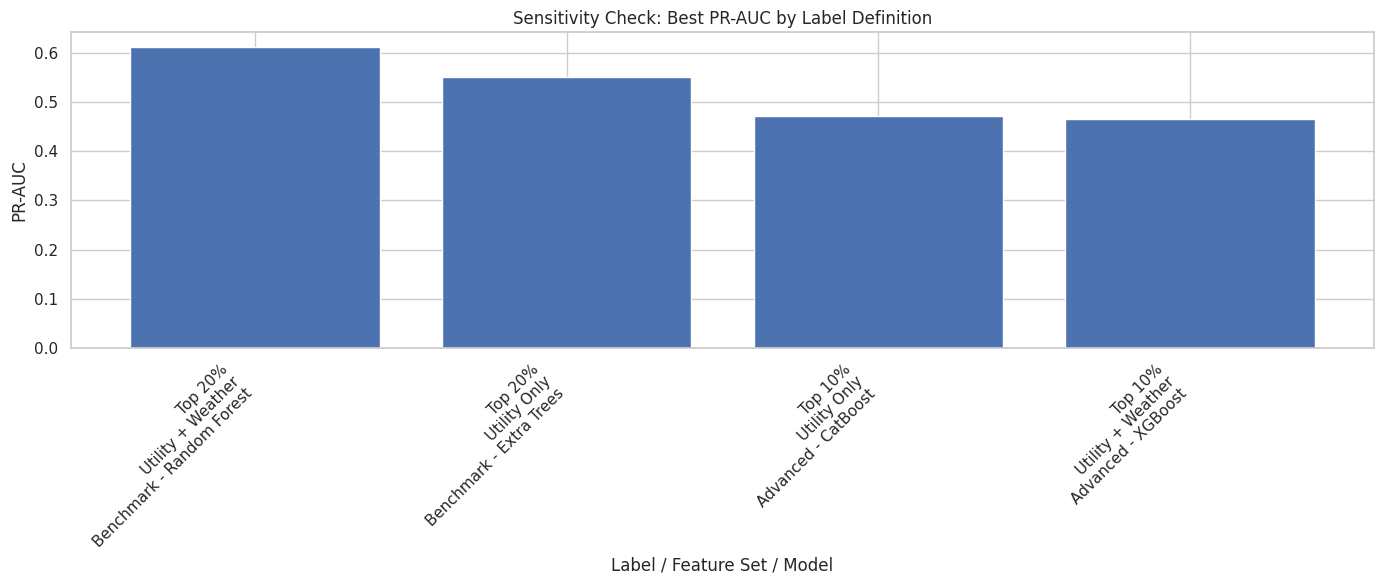

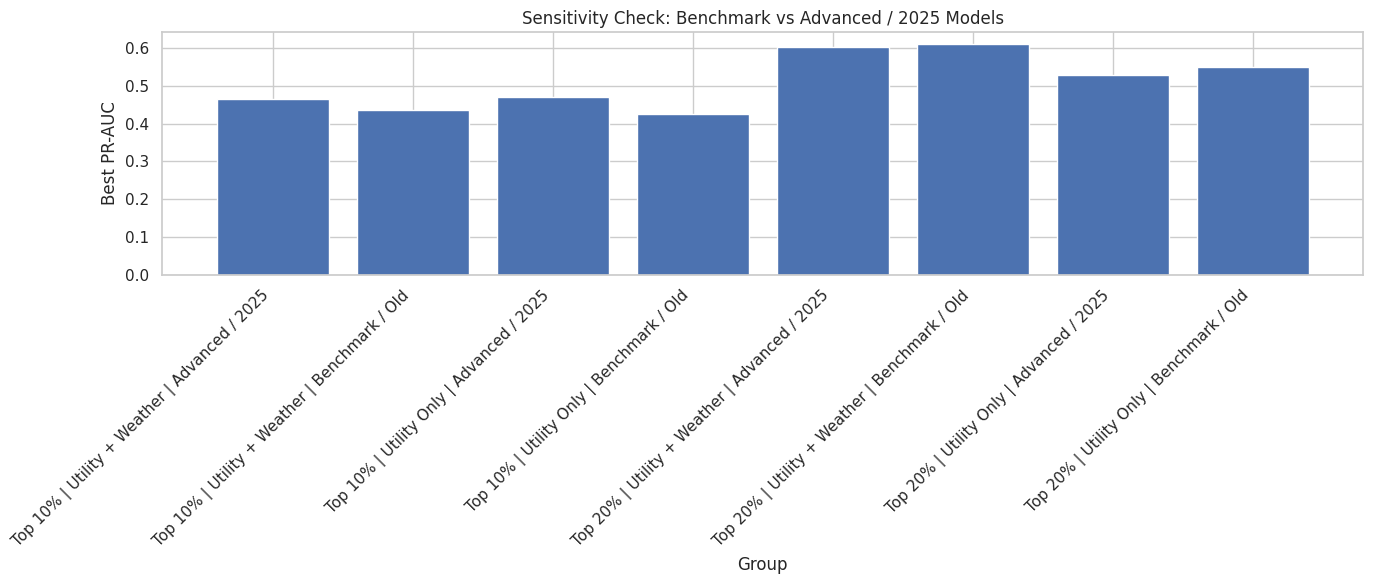

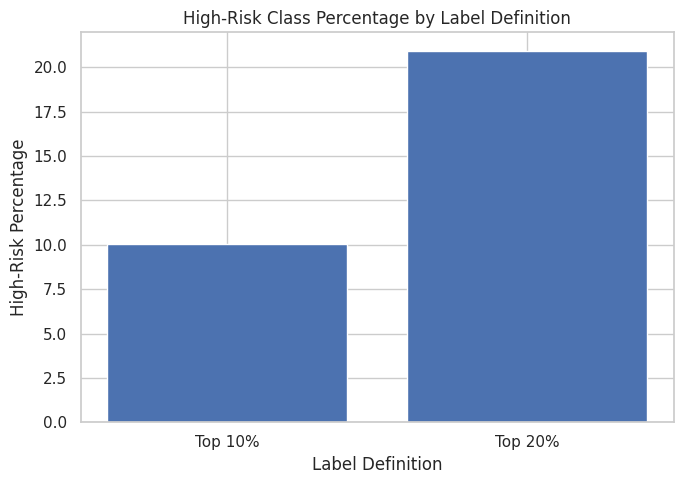

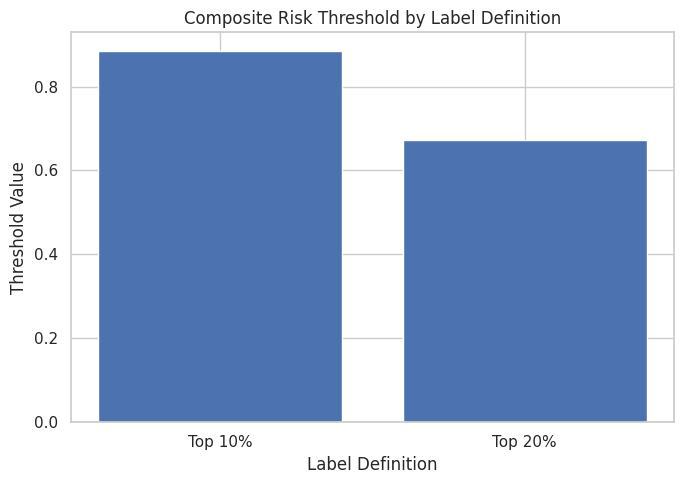

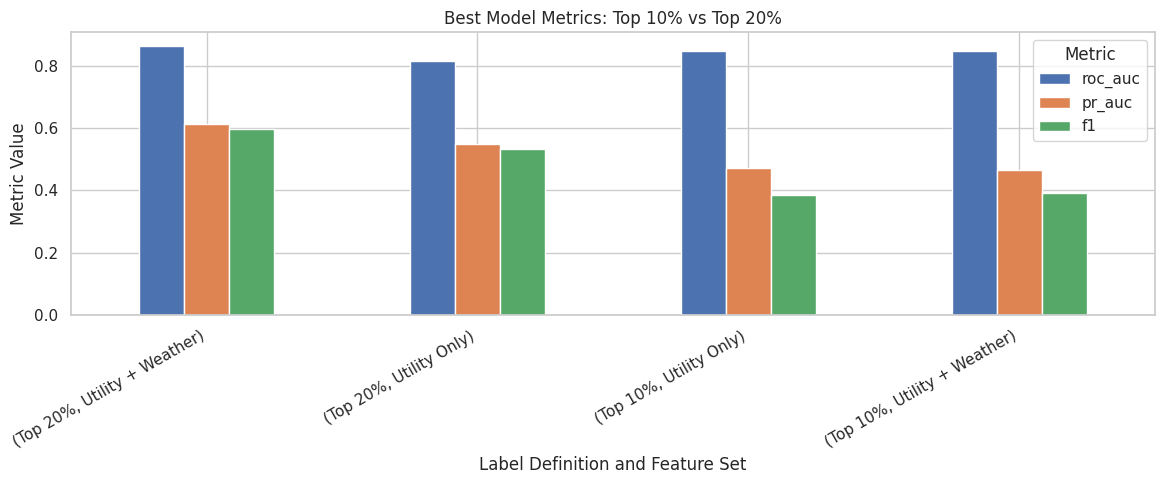

6876

In [7]:
# ============================================================
# CELL 5: SENSITIVITY CHECK TOP 10% VS TOP 20%
# Benchmark vs Advanced vs 2025 Tabular Models
# ============================================================

# Run once in Colab if needed:
# !pip -q install xgboost lightgbm catboost tabpfn mambular

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

warnings.filterwarnings("ignore")

# ============================================================
# SETTINGS
# ============================================================

OUTPUT_DIR = "optimized_modeling_outputs"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MAMBULAR_MAX_EPOCHS = 25
MAMBULAR_LR = 1e-4

utility_data_path = os.path.join(OUTPUT_DIR, "utility_level_modeling_dataset.csv")

if not os.path.exists(utility_data_path):
    raise FileNotFoundError("Run Cell 3 first: utility_level_modeling_dataset.csv not found")

# ============================================================
# OPTIONAL IMPORTS
# ============================================================

HAS_XGB = False
HAS_LGBM = False
HAS_CATBOOST = False
HAS_TABPFN = False
HAS_MAMBULAR_PACKAGE = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    print("XGBoost not available. Install with: !pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    print("LightGBM not available. Install with: !pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    print("CatBoost not available. Install with: !pip install catboost")

try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
except Exception:
    print("TabPFN not available. Install with: !pip install tabpfn")

try:
    import mambular.models as mb_models
    HAS_MAMBULAR_PACKAGE = True
except Exception:
    mb_models = None
    print("Mambular package not available. Install with: !pip install mambular")

# ============================================================
# WRAPPER
# ============================================================

class MambularModelWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_class=None, max_epochs=25, lr=1e-4, random_state=42):
        self.model_class = model_class
        self.max_epochs = max_epochs
        self.lr = lr
        self.random_state = random_state
        self.model_ = None
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        if self.model_class is None:
            raise ValueError("Mambular model_class is None.")

        try:
            self.model_ = self.model_class(random_state=self.random_state)
        except Exception:
            try:
                self.model_ = self.model_class(seed=self.random_state)
            except Exception:
                self.model_ = self.model_class()

        try:
            self.model_.fit(X, y, max_epochs=self.max_epochs, lr=self.lr)
        except TypeError:
            try:
                self.model_.fit(X, y, max_epochs=self.max_epochs)
            except TypeError:
                self.model_.fit(X, y)

        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X))

    def predict_proba(self, X):
        if hasattr(self.model_, "predict_proba"):
            proba = np.asarray(self.model_.predict_proba(X))
            if proba.ndim == 1:
                proba = np.column_stack([1 - proba, proba])
            return proba

        pred = self.predict(X)
        proba = np.zeros((len(pred), 2))
        proba[:, 1] = pred
        proba[:, 0] = 1 - pred
        return proba

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=0.02,
            sparse_output=False
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=0.02,
                sparse=False
            )
        except TypeError:
            return OneHotEncoder(
                handle_unknown="ignore",
                sparse=False
            )

def safe_metric(metric_func, y_true, y_score_or_pred):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return metric_func(y_true, y_score_or_pred)
    except Exception:
        return np.nan

def get_pos_weight(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    return neg / max(pos, 1)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())
        ]), categorical_cols)
    ], remainder="drop")

    return preprocessor

def create_tabpfn_model():
    try:
        return TabPFNClassifier(random_state=RANDOM_STATE)
    except TypeError:
        return TabPFNClassifier()

def add_mambular_model_if_available(model_dict, model_name, class_name):
    if not HAS_MAMBULAR_PACKAGE:
        return

    model_class = getattr(mb_models, class_name, None)

    if model_class is not None:
        model_dict[model_name] = lambda spw, cls=model_class: MambularModelWrapper(
            model_class=cls,
            max_epochs=MAMBULAR_MAX_EPOCHS,
            lr=MAMBULAR_LR,
            random_state=RANDOM_STATE
        )

def make_model_factories():
    benchmark_factories = {
        "Benchmark - Logistic Regression": lambda spw: LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE
        ),

        "Benchmark - Decision Tree": lambda spw: DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

        "Benchmark - Random Forest": lambda spw: RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),

        "Benchmark - Extra Trees": lambda spw: ExtraTreesClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=4,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    }

    advanced_factories = {
        "Advanced - HistGradientBoosting": lambda spw: HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        )
    }

    if HAS_XGB:
        advanced_factories["Advanced - XGBoost"] = lambda spw: XGBClassifier(
            n_estimators=350,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    if HAS_LGBM:
        advanced_factories["Advanced - LightGBM"] = lambda spw: LGBMClassifier(
            n_estimators=350,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

    if HAS_CATBOOST:
        advanced_factories["Advanced - CatBoost"] = lambda spw: CatBoostClassifier(
            iterations=350,
            depth=5,
            learning_rate=0.04,
            loss_function="Logloss",
            eval_metric="AUC",
            scale_pos_weight=spw,
            random_seed=RANDOM_STATE,
            verbose=False
        )

    if HAS_TABPFN:
        advanced_factories["Advanced 2025 - TabPFN"] = lambda spw: create_tabpfn_model()

    add_mambular_model_if_available(advanced_factories, "Advanced 2025 - Mambular", "MambularClassifier")
    add_mambular_model_if_available(advanced_factories, "Advanced 2025 - TabM", "TabMClassifier")
    add_mambular_model_if_available(advanced_factories, "Advanced 2025 - FTTransformer", "FTTransformerClassifier")
    add_mambular_model_if_available(advanced_factories, "Advanced 2025 - Tangos", "TangosClassifier")

    model_factories = {}

    model_factories.update({
        name: ("Benchmark / Old", factory)
        for name, factory in benchmark_factories.items()
    })

    model_factories.update({
        name: ("Advanced / 2025", factory)
        for name, factory in advanced_factories.items()
    })

    return model_factories

# ============================================================
# LOAD UTILITY-LEVEL DATA
# ============================================================

utility_df = pd.read_csv(utility_data_path)
print("Loaded utility-level dataset:", utility_df.shape)

for c in utility_df.columns:
    if utility_df[c].dtype == "object":
        utility_df[c] = utility_df[c].replace(["nan", "None", "NULL", ""], np.nan)

# ============================================================
# FEATURE SETS
# ============================================================

leakage_cols = [
    "high_risk",
    "high_risk_temp",
    "saidi_rank_pct",
    "saifi_rank_pct",
    "composite_outage_risk_score",
    "IEEE_AllEvents_SAIDI_min_per_yr",
    "IEEE_AllEvents_SAIFI_times_per_yr",
    "IEEE_AllEvents_CAIDI_min_per_interruption",
    "IEEE_NoMED_SAIDI_min_per_yr",
    "IEEE_NoMED_SAIFI_times_per_yr",
    "IEEE_NoMED_CAIDI_min_per_interruption",
    "Utility Number",
    "Utility Name"
]

all_candidate_features = [
    c for c in utility_df.columns
    if c not in leakage_cols
]

weather_feature_names = {
    "total_damage_usd",
    "log_total_damage",
    "total_injuries",
    "total_deaths",
    "human_impact_score",
    "MAGNITUDE",
    "max_magnitude",
    "unique_event_types",
    "months_with_events",
    "weather_event_count",
    "storm_episode_count",
    "unique_counties_hit"
}

feature_sets = {
    "Utility Only": [
        c for c in all_candidate_features
        if c not in weather_feature_names
    ],
    "Utility + Weather": all_candidate_features.copy()
}

model_factories = make_model_factories()

print("\nModels included in sensitivity check:")
for name, (group, _) in model_factories.items():
    print(f"- {group}: {name}")

# ============================================================
# SENSITIVITY LOOP
# ============================================================

results = []

for pct in [0.10, 0.20]:
    temp = utility_df.copy()

    temp["saidi_rank_pct"] = temp["IEEE_AllEvents_SAIDI_min_per_yr"].rank(pct=True)
    temp["saifi_rank_pct"] = temp["IEEE_AllEvents_SAIFI_times_per_yr"].rank(pct=True)

    temp["composite_outage_risk_score"] = (
        temp["saidi_rank_pct"] + temp["saifi_rank_pct"]
    ) / 2

    thr = temp["composite_outage_risk_score"].quantile(1 - pct)

    temp["high_risk_temp"] = (
        temp["composite_outage_risk_score"] >= thr
    ).astype(int)

    for feature_set_name, feature_cols in feature_sets.items():
        X = temp[feature_cols].copy()
        y = temp["high_risk_temp"].copy()

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            stratify=y,
            random_state=RANDOM_STATE
        )

        pos_weight = get_pos_weight(y_train)

        for model_name, (model_group, factory) in model_factories.items():
            try:
                preprocessor = build_preprocessor(X_train)
                model = factory(pos_weight)

                pipe = Pipeline([
                    ("prep", preprocessor),
                    ("model", model)
                ])

                pipe.fit(X_train, y_train)

                proba = pipe.predict_proba(X_test)[:, 1]
                pred = (proba >= 0.50).astype(int)

                results.append({
                    "label_definition": f"Top {int(pct * 100)}%",
                    "top_risk_percent": pct,
                    "threshold_value": float(thr),
                    "high_risk_count": int(temp["high_risk_temp"].sum()),
                    "high_risk_percent": round(100 * temp["high_risk_temp"].mean(), 2),
                    "feature_set": feature_set_name,
                    "model_group": model_group,
                    "model": model_name,
                    "model_status": "success",
                    "error_message": "",
                    "accuracy": accuracy_score(y_test, pred),
                    "precision": precision_score(y_test, pred, zero_division=0),
                    "recall": recall_score(y_test, pred, zero_division=0),
                    "f1": f1_score(y_test, pred, zero_division=0),
                    "roc_auc": safe_metric(roc_auc_score, y_test, proba),
                    "pr_auc": safe_metric(average_precision_score, y_test, proba)
                })

                print(f"Done: Top {int(pct * 100)}% | {feature_set_name} | {model_group} | {model_name}")

            except Exception as e:
                print(f"Skipped: Top {int(pct * 100)}% | {feature_set_name} | {model_group} | {model_name} | Error: {e}")

                results.append({
                    "label_definition": f"Top {int(pct * 100)}%",
                    "top_risk_percent": pct,
                    "threshold_value": float(thr),
                    "high_risk_count": int(temp["high_risk_temp"].sum()),
                    "high_risk_percent": round(100 * temp["high_risk_temp"].mean(), 2),
                    "feature_set": feature_set_name,
                    "model_group": model_group,
                    "model": model_name,
                    "model_status": "failed",
                    "error_message": str(e),
                    "accuracy": np.nan,
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1": np.nan,
                    "roc_auc": np.nan,
                    "pr_auc": np.nan
                })

sensitivity_df = pd.DataFrame(results)

sensitivity_df = sensitivity_df.sort_values(
    by=["label_definition", "pr_auc", "roc_auc", "f1"],
    ascending=[True, False, False, False],
    na_position="last"
).reset_index(drop=True)

sensitivity_df.to_csv(
    os.path.join(OUTPUT_DIR, "sensitivity_check_top10_vs_top20_advanced_2025.csv"),
    index=False
)

print("\n===== FULL SENSITIVITY CHECK RESULTS =====")
print(sensitivity_df.round(4))

success_sensitivity_df = sensitivity_df[sensitivity_df["model_status"] == "success"].copy()

if success_sensitivity_df.empty:
    raise ValueError("No sensitivity model trained successfully.")

# ============================================================
# BEST MODEL PER LABEL DEFINITION
# ============================================================

best_sensitivity_df = (
    success_sensitivity_df
    .sort_values(by=["pr_auc", "roc_auc", "f1"], ascending=False)
    .groupby(["label_definition", "feature_set"])
    .head(1)
    .reset_index(drop=True)
)

best_sensitivity_df.to_csv(
    os.path.join(OUTPUT_DIR, "best_sensitivity_models_2025.csv"),
    index=False
)

print("\n===== BEST MODEL PER LABEL + FEATURE SET =====")
print(best_sensitivity_df.round(4))

# ============================================================
# GROUP SUMMARY
# ============================================================

sensitivity_group_summary = (
    success_sensitivity_df
    .groupby(["label_definition", "feature_set", "model_group"])
    .agg(
        best_pr_auc=("pr_auc", "max"),
        avg_pr_auc=("pr_auc", "mean"),
        best_roc_auc=("roc_auc", "max"),
        avg_roc_auc=("roc_auc", "mean"),
        best_f1=("f1", "max"),
        avg_f1=("f1", "mean")
    )
    .reset_index()
)

sensitivity_group_summary.to_csv(
    os.path.join(OUTPUT_DIR, "sensitivity_benchmark_vs_advanced_summary_2025.csv"),
    index=False
)

print("\n===== SENSITIVITY GROUP SUMMARY =====")
print(sensitivity_group_summary.round(4))

print("\nSaved files:")
print("- sensitivity_check_top10_vs_top20_advanced_2025.csv")
print("- best_sensitivity_models_2025.csv")
print("- sensitivity_benchmark_vs_advanced_summary_2025.csv")

# ============================================================
# VISUALS
# ============================================================

plot_df = best_sensitivity_df.copy()
plot_df["label"] = (
    plot_df["label_definition"] + "\n" +
    plot_df["feature_set"] + "\n" +
    plot_df["model"]
)

plt.figure(figsize=(14, 6))
plt.bar(plot_df["label"], plot_df["pr_auc"])
plt.title("Sensitivity Check: Best PR-AUC by Label Definition")
plt.xlabel("Label / Feature Set / Model")
plt.ylabel("PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

summary_plot = sensitivity_group_summary.copy()
summary_plot["label"] = (
    summary_plot["label_definition"] + " | " +
    summary_plot["feature_set"] + " | " +
    summary_plot["model_group"]
)

plt.figure(figsize=(14, 6))
plt.bar(summary_plot["label"], summary_plot["best_pr_auc"])
plt.title("Sensitivity Check: Benchmark vs Advanced / 2025 Models")
plt.xlabel("Group")
plt.ylabel("Best PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

class_balance_plot = (
    sensitivity_df[["label_definition", "high_risk_percent"]]
    .drop_duplicates()
    .sort_values("label_definition")
)

plt.figure(figsize=(7, 5))
plt.bar(
    class_balance_plot["label_definition"],
    class_balance_plot["high_risk_percent"]
)
plt.title("High-Risk Class Percentage by Label Definition")
plt.xlabel("Label Definition")
plt.ylabel("High-Risk Percentage")
plt.tight_layout()
plt.show()

threshold_plot = (
    sensitivity_df[["label_definition", "threshold_value"]]
    .drop_duplicates()
    .sort_values("label_definition")
)

plt.figure(figsize=(7, 5))
plt.bar(
    threshold_plot["label_definition"],
    threshold_plot["threshold_value"]
)
plt.title("Composite Risk Threshold by Label Definition")
plt.xlabel("Label Definition")
plt.ylabel("Threshold Value")
plt.tight_layout()
plt.show()

metric_plot_df = best_sensitivity_df.set_index(
    ["label_definition", "feature_set"]
)[["roc_auc", "pr_auc", "f1"]]

metric_plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Best Model Metrics: Top 10% vs Top 20%")
plt.xlabel("Label Definition and Feature Set")
plt.ylabel("Metric Value")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

gc.collect()